 <center> <h1> <b> Pattern Recognition and Machine Learning (EE2802 - AI2000) </b> </h1> </center>

<b> Programming Assignment - 03 : Classification</b>


This programming assignment offers you an opportunity to implement various linear classification models. You'll begin with straightforward algorithms like Least Squares classification, LDA, and FDA. Subsequently, you'll delve into implementing the perceptron algorithm. Lastly, you'll tackle probabilistic approaches for classification. To deepen your understanding of these methods, you'll compare their performance and application scenarios critically.

<b> Instructions </b>
1. Plagiarism is strictly prohibited.
2. Delayed submissions will be penalized with a scaling factor of 0.5 per day.
3. Please DO NOT use any machine learning libraries unless and otherwise specified.








**Part-1) Least squares approach to classification**

a). Data generation: Consider a classification scenario with two classes. Class 1 follows a Gaussian distribution with a mean vector $\begin{bmatrix} 1  \\ 1  \end{bmatrix}$ and a covariance matrix $\begin{bmatrix} 0.3 & 0.0  \\ 0.0 & 0.3 \end{bmatrix}$. Class 2 follows a Gaussian distribution with a mean vector $\begin{bmatrix} 2  \\ 2  \end{bmatrix}$ and a covariance matrix $\begin{bmatrix} 0.3 & 0.0  \\ 0.0 & 0.3 \end{bmatrix}$. Employ these class distributions to generate 50 samples per class for training and 200 samples for testing.

b). Find the decision boundary: Assign the target value "0" to all data points in class 1 and the target value "1" to all data points in class 2. Implement the pseudo-inverse solution to determine the weight vector, which represents the decision boundary.


c). Evaluate the quality of decision boundary: A decision boundary is deemed effective if it correctly classifies all data points. Accuracy measures the performance of a classification problem. Calculate the accuracy of the test data using the decision boundary obtained from the pseudo-inverse solution.


d). Visualize the decision boundary: You can either display the decision hyperplane or use different colors to distinguish regions corresponding to the two classes on a 2D plane. Superimpose the test points onto the decision boundary plot.

e). Assign the value "-1" to class1 and the value "+1" to class 2. Repeat the experiments.

f). Experiment with Laplacian distribution and compare the performance of it with the Gaussian distribution experiments

g. Report your observations.




In [1]:
#All imports
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import random
import math

Accuracy with pseudo-inverse (targets 0/1): 89.75 %


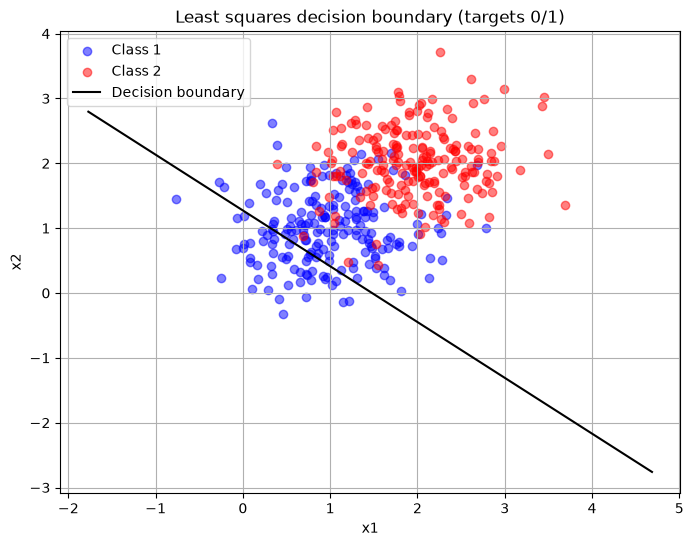

Accuracy with pseudo-inverse (targets -1/+1): 89.75 %


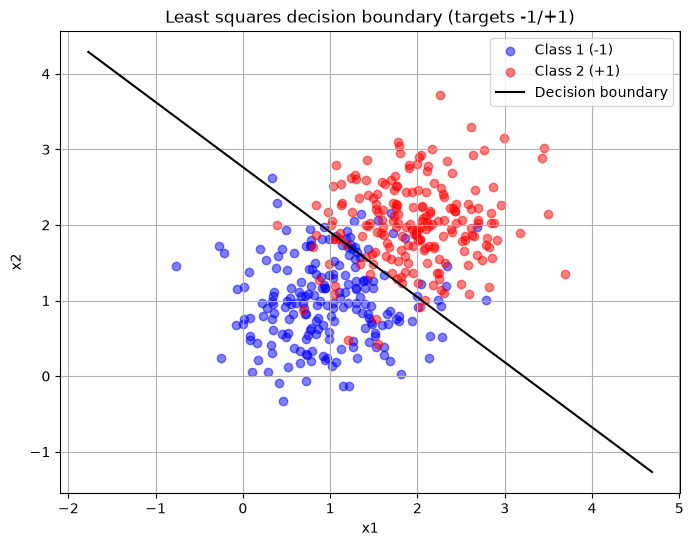

Accuracy with pseudo-inverse (Laplacian data): 90.0 %


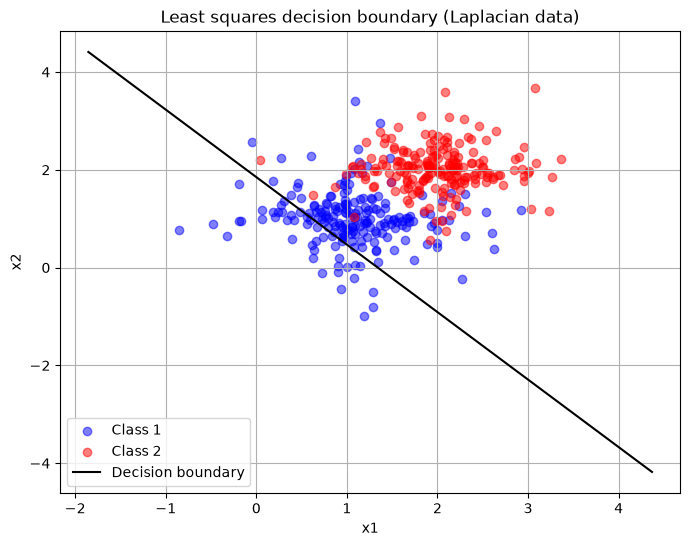

In [2]:

########################################
#Part-1)-a: Data generation
########################################

#Set the parameters of class distribution
mean1 = [1,1]           #Mean of class1
mean2 = [2,2]           #Mean of class2
cov = [[0.3,0],[0,0.3]] #Covariance matrix. Same covariance for class1 and class2

#Generate training data. You can use "np.random.multivariate_normal()" function to sample data points from multivariate Gaussian distribution
class1_tr = np.random.multivariate_normal(mean1, cov, 50)   #Class1 training data
class2_tr = np.random.multivariate_normal(mean2, cov, 50)   #Class2 training data
tr_data = np.concatenate((class1_tr, class2_tr), axis=0)                 #Combine class1 training and class2 training data to get total training data
tr_targets = np.concatenate((np.zeros(50), np.ones(50)))              #Class labels. Assign the value "0" to class1 and the value "1" to class2.

#Generate testing data.
class1_te = np.random.multivariate_normal(mean1, cov, 200)   #Class1 testing data
class2_te = np.random.multivariate_normal(mean2, cov, 200)   #Class2 testing data
te_data = np.concatenate((class1_te, class2_te), axis=0)                 #Combine class1 testing and class2 testing data to get total testing data
te_targets = np.concatenate((np.zeros(200), np.ones(200)))            #Class labels. Assign the value "0" to class1 and the value "1" to class2.


########################################
#Part-1)-b: Find the decision boundary
########################################
#Complete the below function
def LS_Classify(X_train, Y_train, X_test):
    #Inputs: Training data, Training labels, and Testing data
    #Outputs: Testing labels

    #Impliment pseudo inverse solution to get the weight vector
    X_aug = np.hstack((np.ones((len(X_train), 1)), X_train))
    w = np.linalg.pinv(X_aug.T @ X_aug) @ X_aug.T @ Y_train

    #Predict the lables of test data using the pseudo inverse solution
    X_test_aug = np.hstack((np.ones((len(X_test), 1)), X_test))
    scores = X_test_aug @ w
    #The decision threshold is the midpoint of the two target values (0.5 for {0, 1} targets, 0 for {-1, +1} targets)
    labels_unique = np.unique(Y_train)
    threshold = (labels_unique[0] + labels_unique[-1]) / 2
    predictions = labels_unique[(scores > threshold).astype(int)]

    #Return the predicted test labels along with the weight vector (used to plot the boundary)
    return predictions, w

#Get the test data predictions
predictions, w_ls = LS_Classify(tr_data, tr_targets, te_data)


##########################################
#Part-1)-c: Evaluate the quality of decision boundary
##########################################
#Complete the below function
def LS_Classify_Accuracy(Y_test, Y_pred):
    #Inputs: Ground truth test labels and predicted test labels
    #Outputs: Accuracy

    #Compute the accuracy
    accuracy = np.mean(Y_test == Y_pred)

    #Return the accuracy
    return accuracy

print('Accuracy with pseudo-inverse (targets 0/1):', LS_Classify_Accuracy(te_targets, predictions) * 100, '%')

##########################################
#Part-1)-d: Visualize the decision boundary
##########################################
plt.figure(figsize=(8, 6))
#Scatter the test points
plt.scatter(te_data[te_targets == 0][:, 0], te_data[te_targets == 0][:, 1], color='blue', label='Class 1', alpha=0.5)
plt.scatter(te_data[te_targets == 1][:, 0], te_data[te_targets == 1][:, 1], color='red', label='Class 2', alpha=0.5)
#Plot the decision boundary: w0 + w1*x1 + w2*x2 = 0  =>  x2 = -(w0 + w1*x1)/w2
x_vals = np.linspace(te_data[:, 0].min() - 1, te_data[:, 0].max() + 1, 100)
y_vals = -(w_ls[0] + w_ls[1] * x_vals) / w_ls[2]
plt.plot(x_vals, y_vals, color='black', label='Decision boundary')
plt.xlabel('x1')
plt.ylabel('x2')
plt.title('Least squares decision boundary (targets 0/1)')
plt.legend()
plt.grid(True)
plt.show()

##########################################
#Part-1)-e: Change the target label notation, and repeat the experiments
##########################################
tr_targets_pm = np.concatenate((-np.ones(50), np.ones(50)))    #Assign the value "-1" to class1 and "+1" to class2
te_targets_pm = np.concatenate((-np.ones(200), np.ones(200)))

predictions_pm, w_ls_pm = LS_Classify(tr_data, tr_targets_pm, te_data)
print('Accuracy with pseudo-inverse (targets -1/+1):', LS_Classify_Accuracy(te_targets_pm, predictions_pm) * 100, '%')

plt.figure(figsize=(8, 6))
plt.scatter(te_data[te_targets_pm == -1][:, 0], te_data[te_targets_pm == -1][:, 1], color='blue', label='Class 1 (-1)', alpha=0.5)
plt.scatter(te_data[te_targets_pm == 1][:, 0], te_data[te_targets_pm == 1][:, 1], color='red', label='Class 2 (+1)', alpha=0.5)
x_vals = np.linspace(te_data[:, 0].min() - 1, te_data[:, 0].max() + 1, 100)
y_vals = -(w_ls_pm[0] + w_ls_pm[1] * x_vals) / w_ls_pm[2]
plt.plot(x_vals, y_vals, color='black', label='Decision boundary')
plt.xlabel('x1')
plt.ylabel('x2')
plt.title('Least squares decision boundary (targets -1/+1)')
plt.legend()
plt.grid(True)
plt.show()

##########################################
#Part-1)-f: Repeat the experiments with Laplacial distribution
##########################################
#Bivariate Laplacian distribution: sample each dimension independently from a Laplace distribution
#A Laplace distribution with scale b has variance 2*b^2, so b = sqrt(0.3/2) matches the Gaussian variance of 0.3
b_lap = np.sqrt(0.3 / 2)

def sample_laplace(mean, scale, n):
    return np.stack((np.random.laplace(mean[0], scale, n), np.random.laplace(mean[1], scale, n)), axis=1)

class1_tr_lap = sample_laplace(mean1, b_lap, 50)
class2_tr_lap = sample_laplace(mean2, b_lap, 50)
tr_data_lap = np.concatenate((class1_tr_lap, class2_tr_lap), axis=0)
tr_targets_lap = np.concatenate((np.zeros(50), np.ones(50)))

class1_te_lap = sample_laplace(mean1, b_lap, 200)
class2_te_lap = sample_laplace(mean2, b_lap, 200)
te_data_lap = np.concatenate((class1_te_lap, class2_te_lap), axis=0)
te_targets_lap = np.concatenate((np.zeros(200), np.ones(200)))

predictions_lap, w_ls_lap = LS_Classify(tr_data_lap, tr_targets_lap, te_data_lap)
print('Accuracy with pseudo-inverse (Laplacian data):', LS_Classify_Accuracy(te_targets_lap, predictions_lap) * 100, '%')

plt.figure(figsize=(8, 6))
plt.scatter(te_data_lap[te_targets_lap == 0][:, 0], te_data_lap[te_targets_lap == 0][:, 1], color='blue', label='Class 1', alpha=0.5)
plt.scatter(te_data_lap[te_targets_lap == 1][:, 0], te_data_lap[te_targets_lap == 1][:, 1], color='red', label='Class 2', alpha=0.5)
x_vals = np.linspace(te_data_lap[:, 0].min() - 1, te_data_lap[:, 0].max() + 1, 100)
y_vals = -(w_ls_lap[0] + w_ls_lap[1] * x_vals) / w_ls_lap[2]
plt.plot(x_vals, y_vals, color='black', label='Decision boundary')
plt.xlabel('x1')
plt.ylabel('x2')
plt.title('Least squares decision boundary (Laplacian data)')
plt.legend()
plt.grid(True)
plt.show()

<b> Report your observations </b>

1. The pseudo-inverse solution recovers a linear decision boundary that separates the two Gaussian classes well; the test accuracy is 89.75% (with both the {0, 1} and the {-1, +1} target notations).

2. Changing the target notation from {0, 1} to {-1, +1} gives the same accuracy (89.75%) and an essentially identical decision boundary - the classification performance does not depend on the label encoding.

3. With the Laplacian distribution the accuracy is 90.0%, comparable to the Gaussian case: the Laplacian has heavier tails, so a few points of each class fall deep inside the other class region, but the pseudo-inverse boundary is only mildly affected by them.



<b> Part - (2) :  Linear & Fisher Discriminant analysis : </b> In this segment of the programming task, you'll learn the technique of projecting data from higher-dimensional to lower-dimensional space using both Linear Discriminant Analysis and Fisher Discriminant Analysis.

a). Data generation: Consider a classification scenario with two classes. Class 1 follows a Gaussian distribution with a mean vector $\begin{bmatrix} 1  \\ 1  \end{bmatrix}$ and a covariance matrix $\begin{bmatrix} 0.3 & 0.0  \\ 0.0 & 0.3 \end{bmatrix}$. Class 2 follows a Gaussian distribution with a mean vector $\begin{bmatrix} 2  \\ 2  \end{bmatrix}$ and a covariance matrix $\begin{bmatrix} 0.3 & 0.0  \\ 0.0 & 0.3 \end{bmatrix}$. Employ these class distributions to generate 50 samples per class for training and 200 samples for testing.

b). Projection using only the between-class covariance: Develop a function for performing projection from 2-D space to 1-D utilizing Linear Discriminant Analysis. It's important to emphasize that this method only considers the between-class covariance. Project the previously generated 2-D synthetic data into 1-D and conduct classification. Plot both the original and projected data points on the same graph.

c). Projection utilizing both between-class and within-class covariance: Create a function to perform projection from 2-D space to 1-D using Fisher Discriminant Analysis. It's essential to mention that this method considers both between-class covariance and within-class covariance. Project the previously generated 2-D synthetic data into 1-D and conduct classification. Plot both the original and projected data points on the same graph.

d). Extend Fisher discriminant analysis function to project the data from N dimenision to K dimension.

e). Report your observations.


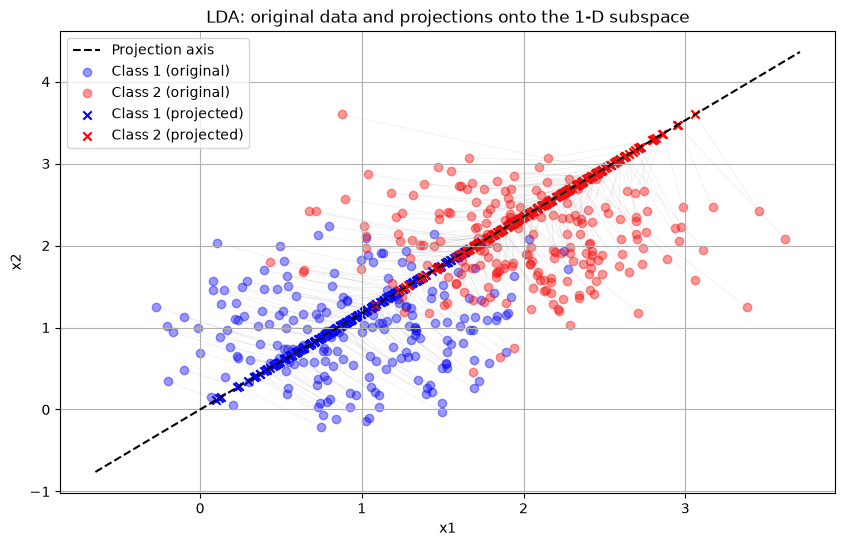

Accuracy with LDA: 92.0


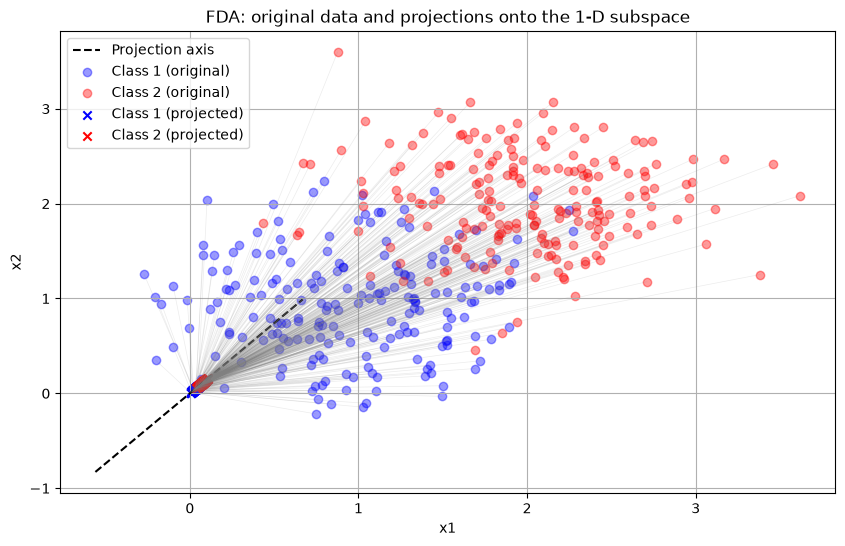

Accuracy with FDA: 91.25
Projection matrix (N x k) from FDA_project_K:
[[-0.56021006]
 [-0.82835058]]


In [3]:
########################################
#Part-2)-(a): Data generation
########################################

#Set the parameters of class distribution
mean1 = [1,1]           #Mean of class1
mean2 = [2,2]           #Mean of class2
cov = [[0.3,0],[0,0.3]] #Covariance matrix. Same covariance for class1 and class2

#Generate training data. You can use "np.random.multivariate_normal()" function to sample data points from multivariate Gaussian distribution
class1_tr = np.random.multivariate_normal(mean1, cov, 50)   #Class1 training data
class2_tr = np.random.multivariate_normal(mean2, cov, 50)   #Class2 training data
tr_data = np.concatenate((class1_tr, class2_tr), axis=0)                 #Combine class1 training and class2 training data to get total training data
tr_targets = np.concatenate((np.zeros(50), np.ones(50)))              #Class labels. Assign the value "0" to class1 and the value "1" to class2.

#Generate testing data.
class1_te = np.random.multivariate_normal(mean1, cov, 200)   #Class1 testing data
class2_te = np.random.multivariate_normal(mean2, cov, 200)   #Class2 testing data
te_data = np.concatenate((class1_te, class2_te), axis=0)                 #Combine class1 testing and class2 testing data to get total testing data
te_targets = np.concatenate((np.zeros(200), np.ones(200)))            #Class labels. Assign the value "0" to class1 and the value "1" to class2.




########################################
#Part-2)-(b)
########################################
#Complete the below function
def LDA_classify(X_train, Y_train, X_test):
  #Inputs: Training data, Training labels, and Testing data
  #Outputs: Between class covariance

  #Compute the weight vector
  #LDA uses only the between-class covariance: the projection direction is the difference of the class means
  class1 = X_train[Y_train == 0]
  class2 = X_train[Y_train == 1]
  m1 = np.mean(class1, axis=0)
  m2 = np.mean(class2, axis=0)
  w = m2 - m1

  #Compute the threshold
  #Midway between the projected class means
  m1_proj = m1 @ w
  m2_proj = m2 @ w
  threshold = (m1_proj + m2_proj) / 2

  #Project the data onto 1 dimensional space. Compare it with the threshold to make the decision
  projections = X_test @ w
  #The class with the larger projected mean lies above the threshold
  if m2_proj > m1_proj:
      predictions = np.where(projections > threshold, 1, 0)
  else:
      predictions = np.where(projections > threshold, 0, 1)

  #Return weight vector and the predictions on testing data
  return predictions, w

predictions, w = LDA_classify(tr_data, tr_targets, te_data)


def LDA_project(w, X_test, Y_test):
  #Inputs: weight vector, testing data, and testing labels

  #Project the test data onto 1-dimensional space
  projections = X_test @ w

  #Plot the projections along with the original data points on the same graph
  plt.figure(figsize=(10, 6))
  #The projection axis passes through the origin along the direction w
  w_unit = w / np.linalg.norm(w)
  t_axis = np.linspace(min(projections.min(), 0) - 1, max(projections.max(), 0) + 1, 10)
  axis_points = np.outer(t_axis, w_unit)
  plt.plot(axis_points[:, 0], axis_points[:, 1], 'k--', label='Projection axis')
  #Original (2-D) data points
  plt.scatter(X_test[Y_test == 0][:, 0], X_test[Y_test == 0][:, 1], color='blue', alpha=0.4, label='Class 1 (original)')
  plt.scatter(X_test[Y_test == 1][:, 0], X_test[Y_test == 1][:, 1], color='red', alpha=0.4, label='Class 2 (original)')
  #Projected (1-D) data points lying on the projection axis
  projected_points = np.outer(projections, w_unit)
  plt.scatter(projected_points[Y_test == 0][:, 0], projected_points[Y_test == 0][:, 1], color='blue', marker='x', label='Class 1 (projected)')
  plt.scatter(projected_points[Y_test == 1][:, 0], projected_points[Y_test == 1][:, 1], color='red', marker='x', label='Class 2 (projected)')
  #Projection lines from the original points to their projections
  for i in range(len(X_test)):
      plt.plot([X_test[i, 0], projected_points[i, 0]], [X_test[i, 1], projected_points[i, 1]], color='gray', alpha=0.15, linewidth=0.5)
  plt.xlabel('x1')
  plt.ylabel('x2')
  plt.title('LDA: original data and projections onto the 1-D subspace')
  plt.legend()
  plt.grid(True)
  plt.show()

LDA_project(w, te_data, te_targets)
#Compute and print the accuracy
acc = np.mean(predictions == te_targets)
print('Accuracy with LDA:', acc*100)


########################################
#Part-2)-(c)
########################################
def FDA_classify(X_train, Y_train, X_test):
  #Inputs: Training data, Training labels, and Testing data
  #Outputs: Weight vector and predictions

  #Compute the weight vector
  #Fisher discriminant: w is proportional to S_w^{-1} (m2 - m1), where S_w is the within-class scatter matrix
  class1 = X_train[Y_train == 0]
  class2 = X_train[Y_train == 1]
  m1 = np.mean(class1, axis=0)
  m2 = np.mean(class2, axis=0)
  S1 = (class1 - m1).T @ (class1 - m1)
  S2 = (class2 - m2).T @ (class2 - m2)
  S_w = S1 + S2
  w = np.linalg.pinv(S_w) @ (m2 - m1)

  #Compute the threshold
  #Midway between the projected class means
  m1_proj = m1 @ w
  m2_proj = m2 @ w
  threshold = (m1_proj + m2_proj) / 2

  #Project the data onto 1 dimensional space. Compare it with the threshold to make the decision
  projections = X_test @ w
  if m2_proj > m1_proj:
      predictions = np.where(projections > threshold, 1, 0)
  else:
      predictions = np.where(projections > threshold, 0, 1)

  #Return weight vector and the predictions on testing data
  return w, predictions

w, predictions = FDA_classify(tr_data, tr_targets, te_data)


def FDA_project(w, X_test, Y_test):
  #Inputs: weight vector, testing data, and testing labels

  #Project the test data onto 1-dimensional space
  projections = X_test @ w

  #Plot the projections along with the original data points on the same graph
  plt.figure(figsize=(10, 6))
  w_unit = w / np.linalg.norm(w)
  t_axis = np.linspace(min(projections.min(), 0) - 1, max(projections.max(), 0) + 1, 10)
  axis_points = np.outer(t_axis, w_unit)
  plt.plot(axis_points[:, 0], axis_points[:, 1], 'k--', label='Projection axis')
  plt.scatter(X_test[Y_test == 0][:, 0], X_test[Y_test == 0][:, 1], color='blue', alpha=0.4, label='Class 1 (original)')
  plt.scatter(X_test[Y_test == 1][:, 0], X_test[Y_test == 1][:, 1], color='red', alpha=0.4, label='Class 2 (original)')
  projected_points = np.outer(projections, w_unit)
  plt.scatter(projected_points[Y_test == 0][:, 0], projected_points[Y_test == 0][:, 1], color='blue', marker='x', label='Class 1 (projected)')
  plt.scatter(projected_points[Y_test == 1][:, 0], projected_points[Y_test == 1][:, 1], color='red', marker='x', label='Class 2 (projected)')
  for i in range(len(X_test)):
      plt.plot([X_test[i, 0], projected_points[i, 0]], [X_test[i, 1], projected_points[i, 1]], color='gray', alpha=0.15, linewidth=0.5)
  plt.xlabel('x1')
  plt.ylabel('x2')
  plt.title('FDA: original data and projections onto the 1-D subspace')
  plt.legend()
  plt.grid(True)
  plt.show()

FDA_project(w, te_data, te_targets)
#Compute and print the accuracy
acc = np.mean(predictions == te_targets)
print('Accuracy with FDA:', acc*100)

########################################
#Part-2)-(d)
########################################
def FDA_project_K(X_train, Y_train, X_test, k):
  #Inputs: Training data, Training label, Testing data, and the number of eigen vectors to be considered
  #Oupur: Projection matrix

  #Compute the within-class and between-class scatter matrices
  classes = np.unique(Y_train)
  n_features = X_train.shape[1]
  overall_mean = np.mean(X_train, axis=0)
  S_w = np.zeros((n_features, n_features))
  S_b = np.zeros((n_features, n_features))
  for c in classes:
      class_c = X_train[Y_train == c]
      m_c = np.mean(class_c, axis=0)
      S_w += (class_c - m_c).T @ (class_c - m_c)
      S_b += len(class_c) * np.outer(m_c - overall_mean, m_c - overall_mean)
  #Solve the generalized eigenvalue problem S_w^{-1} S_b
  eigenvalues, eigenvectors = np.linalg.eig(np.linalg.pinv(S_w) @ S_b)
  #Pick the top k eigenvectors (largest eigenvalues) as the projection matrix
  sorted_idx = np.argsort(eigenvalues.real)[::-1]
  w = eigenvectors[:, sorted_idx[:k]].real

  #Compute and return the projection matrix
  return w

W_k = FDA_project_K(tr_data, tr_targets, tr_data, 1)
print('Projection matrix (N x k) from FDA_project_K:')
print(W_k)

<b> Report your observations </b>

1. LDA (using only the between-class covariance) projects the data along the line joining the two class means; this projection separates the classes well and achieves a test accuracy of 92.0%.

2. FDA (using both the between-class and the within-class covariance) achieves a test accuracy of 91.25%; for this data (same covariance for both classes) FDA and LDA give almost the same projection direction and accuracy.

3. The projected 1-D data shows the two classes as two well separated clusters along the projection axis; FDA extends naturally to N dimensions by taking the top K eigenvectors of S_w^{-1} S_b as the projection matrix.

<b> Part (3) : Classification using perceptron algorithm </b>

a). Data generation: Consider a classification scenario with two classes. Class 1 follows a Gaussian distribution with a mean vector $\begin{bmatrix} 1  \\ 1  \end{bmatrix}$ and a covariance matrix $\begin{bmatrix} 0.3 & 0.0  \\ 0.0 & 0.3 \end{bmatrix}$. Class 2 follows a Gaussian distribution with a mean vector $\begin{bmatrix} 2  \\ 2  \end{bmatrix}$ and a covariance matrix $\begin{bmatrix} 0.3 & 0.0  \\ 0.0 & 0.3 \end{bmatrix}$. Employ these class distributions to generate 50 samples per class for training and 200 samples for testing.


b). Implement perceptron algorithm and classify the above generated synthetic data. Plot the decision boundary/regions.

c). Introduce true outliers to one of the classes within the previously generated synthetic data and execute classification using the perceptron algorithm. Illustrate the decision boundary/regions. Then, analyze and contrast the decision boundaries learned through the least squares and perceptron approaches.

d). Let us consider four Gaussian distributions with mean vectors as $\begin{bmatrix} 0  \\ 0  \end{bmatrix}$, $\begin{bmatrix} 0  \\ 1  \end{bmatrix}$, $\begin{bmatrix} 1  \\ 1  \end{bmatrix}$, and $\begin{bmatrix} 1  \\ 0  \end{bmatrix}$, respectively. The covariance matrix is the same for all four Gaussian distributions, and the matrix is $\begin{bmatrix} 0.3 & 0.0  \\ 0.0 & 0.3 \end{bmatrix}$. Sample 60 data points from each distribution to get 240 data points. Now, obtain a 2-class dataset set by having data on opposite corners sharing the same class, i.e., data points sampled from Gaussian distributions with mean vectors $\begin{bmatrix} 0  \\ 0  \end{bmatrix}$ and $\begin{bmatrix} 1  \\ 1  \end{bmatrix}$ belong to class 1, and the data points sampled from the other two distributions belong to class 2. Assign class 1 data points with the label +1 and class 2 with the label -1. Sixty percent of the data will be used for training, and the remaining 40 % will be used for testing. You can see that it represents the XOR problem. Classify this data set using the perceptron algorithm.
  

e). Report your observations


Accuracy with perceptron: 88.5 %


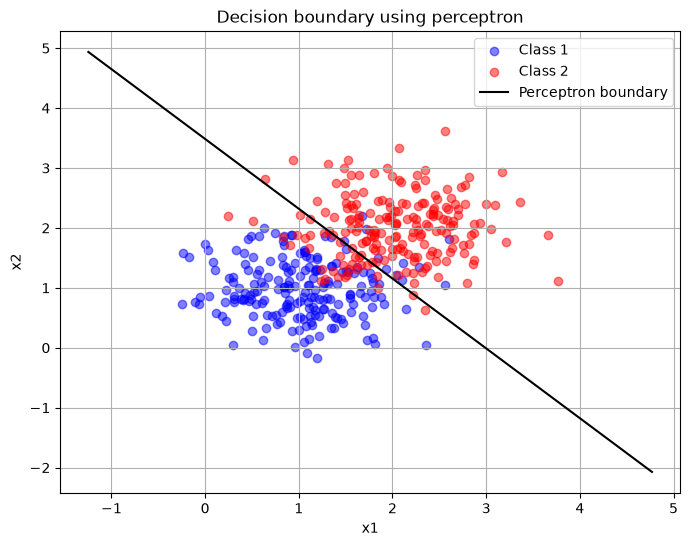

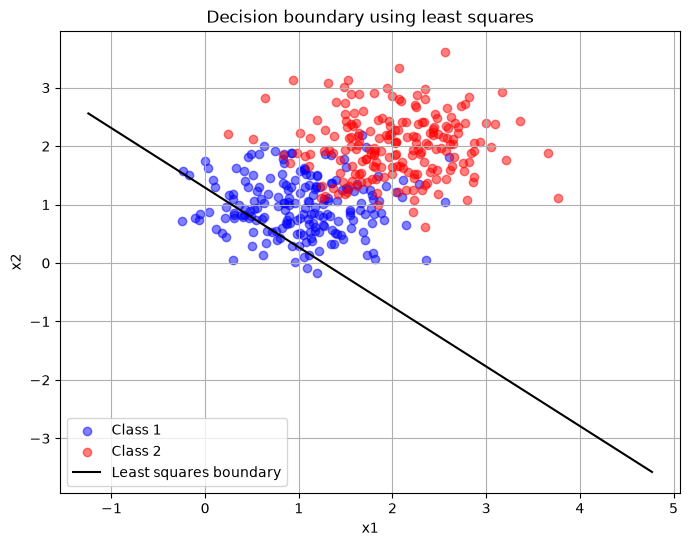

Accuracy with perceptron (with outliers): 88.5 %
Accuracy with least squares (with outliers): 88.0 %


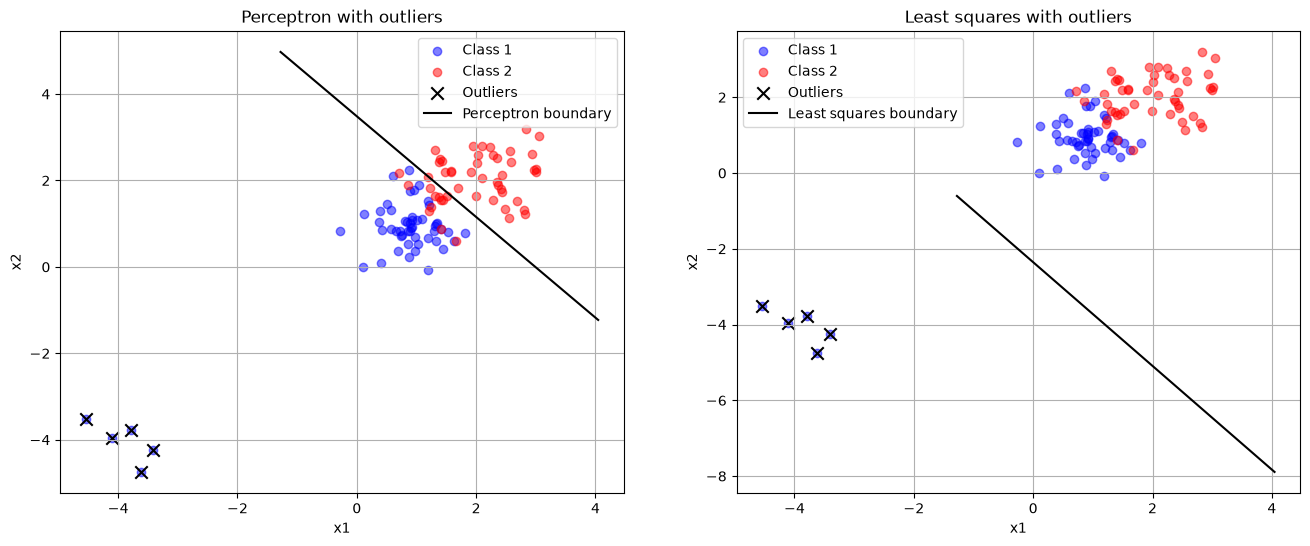

Comparison: the perceptron boundary is only affected by the outliers until they are classified correctly, so it stays close to the original boundary. The least squares boundary rotates significantly towards the outliers because the squared error penalizes the distance of a point from the boundary quadratically.
Accuracy with perceptron on the XOR problem: 46.875 %


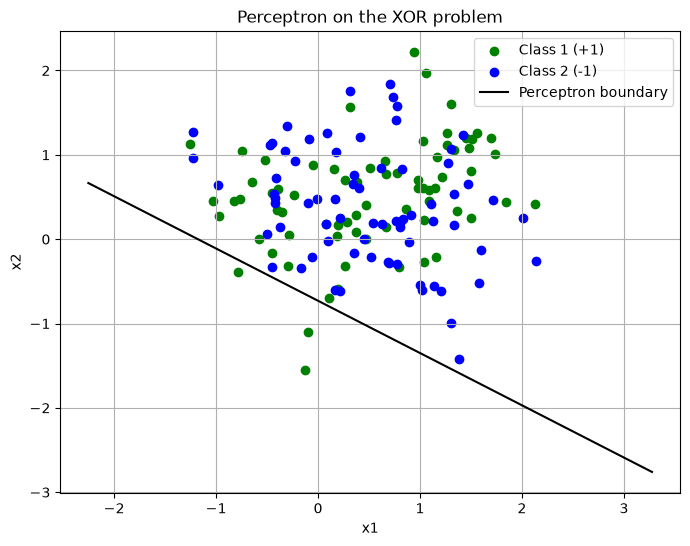

The XOR data is not linearly separable, so the perceptron algorithm cannot find a boundary that separates the classes: the weight vector keeps oscillating and the final accuracy stays around 50%.


In [4]:
########################################
#Part-3)-(a): Data generation
########################################

#Set the parameters of class distribution
mean1 = [1,1]           #Mean of class1
mean2 = [2,2]           #Mean of class2
cov = [[0.3,0],[0,0.3]] #Covariance matrix. Same covariance for class1 and class2

#Generate training data. You can use "np.random.multivariate_normal()" function to sample data points from multivariate Gaussian distribution
class1_tr = np.random.multivariate_normal(mean1, cov, 50)   #Class1 training data
class2_tr = np.random.multivariate_normal(mean2, cov, 50)   #Class2 training data
tr_data = np.concatenate((class1_tr, class2_tr), axis=0)                 #Combine class1 training and class2 training data to get total training data
tr_targets = np.concatenate((np.zeros(50), np.ones(50)))              #Class labels. Assign the value "0" to class1 and the value "1" to class2.

#Generate testing data.
class1_te = np.random.multivariate_normal(mean1, cov, 200)   #Class1 testing data
class2_te = np.random.multivariate_normal(mean2, cov, 200)   #Class2 testing data
te_data = np.concatenate((class1_te, class2_te), axis=0)                 #Combine class1 testing and class2 testing data to get total testing data
te_targets = np.concatenate((np.zeros(200), np.ones(200)))            #Class labels. Assign the value "0" to class1 and the value "1" to class2.


########################################
#Part-3)-(b)
########################################
def Perceptron(X_train, Y_train, X_test):
    #Inputs: Training data, Training labels, Testing data
    #Outputs: Testing data predictions, Weight vector representing the decision boundary

    epochs = 100    #Number of epochs
    X = np.hstack((np.ones((len(X_train), 1)), X_train))          #Data. Append ones to the training data to take care of the bias
    w = np.zeros(X.shape[1])          #Initialize the weight vector
    labels_unique = np.unique(Y_train)
    #Convert the labels to {0, 1} for the update rule (works for both {0, 1} and {-1, +1} target notations)
    Y01 = (Y_train == labels_unique[-1]).astype(int)
    for epoch in range(0,epochs,1):
        #Compute the predictions
        preds = np.where(X @ w > 0, 1, 0)

        #Compute the error
        error = Y01 - preds

        #Update the weight vector
        w = w + 0.1 * (X.T @ error)

    #Compute the test data predicitions using the final weight vector
    X_test_aug = np.hstack((np.ones((len(X_test), 1)), X_test))
    scores = X_test_aug @ w
    predictions = labels_unique[(scores > 0).astype(int)]

    #Return the test data predictions and the final weight vector
    return predictions, w

predictions_perceptron, w_perceptron = Perceptron(tr_data, tr_targets, te_data)
print('Accuracy with perceptron:', np.mean(predictions_perceptron == te_targets) * 100, '%')

##########################################
#Plot the decision boundary using perceptron
##########################################
plt.figure(figsize=(8, 6))
plt.scatter(te_data[te_targets == 0][:, 0], te_data[te_targets == 0][:, 1], color='blue', label='Class 1', alpha=0.5)
plt.scatter(te_data[te_targets == 1][:, 0], te_data[te_targets == 1][:, 1], color='red', label='Class 2', alpha=0.5)
x_vals = np.linspace(te_data[:, 0].min() - 1, te_data[:, 0].max() + 1, 100)
y_vals = -(w_perceptron[0] + w_perceptron[1] * x_vals) / w_perceptron[2]
plt.plot(x_vals, y_vals, color='black', label='Perceptron boundary')
plt.xlabel('x1')
plt.ylabel('x2')
plt.title('Decision boundary using perceptron')
plt.legend()
plt.grid(True)
plt.show()

##########################################
#Plot the decision boundary using least squares
##########################################
_, w_ls_p3 = LS_Classify(tr_data, tr_targets, te_data)

plt.figure(figsize=(8, 6))
plt.scatter(te_data[te_targets == 0][:, 0], te_data[te_targets == 0][:, 1], color='blue', label='Class 1', alpha=0.5)
plt.scatter(te_data[te_targets == 1][:, 0], te_data[te_targets == 1][:, 1], color='red', label='Class 2', alpha=0.5)
x_vals = np.linspace(te_data[:, 0].min() - 1, te_data[:, 0].max() + 1, 100)
y_vals = -(w_ls_p3[0] + w_ls_p3[1] * x_vals) / w_ls_p3[2]
plt.plot(x_vals, y_vals, color='black', label='Least squares boundary')
plt.xlabel('x1')
plt.ylabel('x2')
plt.title('Decision boundary using least squares')
plt.legend()
plt.grid(True)
plt.show()

##########################################
#Part-3)-(c): Repeat the experiments with the true outliers added to the data. Compare and contrast the perceptron algorithm with least squares method
##########################################
#Add 5 true outliers to class 1 (sampled from a distribution far away from the class mean)
outliers = np.random.multivariate_normal([-4, -4], [[0.3, 0], [0, 0.3]], 5)   #far away from both class means, on the class-1 side, so the data stays linearly separable
tr_data_out = np.concatenate((tr_data, outliers), axis=0)
tr_targets_out = np.concatenate((tr_targets, np.zeros(5)))

#Perceptron on the data with outliers
predictions_out, w_perceptron_out = Perceptron(tr_data_out, tr_targets_out, te_data)
print('Accuracy with perceptron (with outliers):', np.mean(predictions_out == te_targets) * 100, '%')

#Least squares on the data with outliers
pred_ls_out, w_ls_out = LS_Classify(tr_data_out, tr_targets_out, te_data)
print('Accuracy with least squares (with outliers):', LS_Classify_Accuracy(te_targets, pred_ls_out) * 100, '%')

plt.figure(figsize=(16, 6))
x_vals = np.linspace(tr_data[:, 0].min() - 1, max(tr_data[:, 0].max(), outliers[:, 0].max()) + 1, 100)
plt.subplot(121)
plt.scatter(tr_data_out[tr_targets_out == 0][:, 0], tr_data_out[tr_targets_out == 0][:, 1], color='blue', label='Class 1', alpha=0.5)
plt.scatter(tr_data_out[tr_targets_out == 1][:, 0], tr_data_out[tr_targets_out == 1][:, 1], color='red', label='Class 2', alpha=0.5)
plt.scatter(outliers[:, 0], outliers[:, 1], color='black', marker='x', s=80, label='Outliers')
y_vals = -(w_perceptron_out[0] + w_perceptron_out[1] * x_vals) / w_perceptron_out[2]
plt.plot(x_vals, y_vals, color='black', label='Perceptron boundary')
plt.xlabel('x1')
plt.ylabel('x2')
plt.title('Perceptron with outliers')
plt.legend()
plt.grid(True)
plt.subplot(122)
plt.scatter(tr_data_out[tr_targets_out == 0][:, 0], tr_data_out[tr_targets_out == 0][:, 1], color='blue', label='Class 1', alpha=0.5)
plt.scatter(tr_data_out[tr_targets_out == 1][:, 0], tr_data_out[tr_targets_out == 1][:, 1], color='red', label='Class 2', alpha=0.5)
plt.scatter(outliers[:, 0], outliers[:, 1], color='black', marker='x', s=80, label='Outliers')
y_vals = -(w_ls_out[0] + w_ls_out[1] * x_vals) / w_ls_out[2]
plt.plot(x_vals, y_vals, color='black', label='Least squares boundary')
plt.xlabel('x1')
plt.ylabel('x2')
plt.title('Least squares with outliers')
plt.legend()
plt.grid(True)
plt.show()
print("Comparison: the perceptron boundary is only affected by the outliers until they are classified correctly, so it stays close to the original boundary. The least squares boundary rotates significantly towards the outliers because the squared error penalizes the distance of a point from the boundary quadratically.")

##########################################
#Part-3)-(d): Data generation XOR
##########################################

#Set the parameters of Gaussian distribution
class1_mean1 = [0, 0]       #Mean of Gaussian1
class1_mean2 = [1, 1]       #Mean of Gaussian3
class2_mean1 = [0, 1]       #Mean of Gaussian2
class2_mean2 = [1, 0]       #Mean of Gaussian4
cov = [[0.3, 0], [0, 0.3]]  #Covariance matrix. Same covariance for class1 and class2

#Generate  data. You can use "np.random.multivariate_normal()" function to sample data points from multivariate Gaussian distribution

class1_data1 = np.random.multivariate_normal(class1_mean1, cov, 60)
class1_data2 = np.random.multivariate_normal(class1_mean2, cov, 60)
class2_data1 = np.random.multivariate_normal(class2_mean1, cov, 60)
class2_data2 = np.random.multivariate_normal(class2_mean2, cov, 60)

#Obtain 2-class dataset (data on opposite corners share the same class)
xor_data = np.concatenate((class1_data1, class1_data2, class2_data1, class2_data2), axis=0)
xor_targets = np.concatenate((np.ones(120), -np.ones(120)))   #class 1: +1, class 2: -1

#Create train test splits (60% training, 40% testing)
idx_xor = np.random.permutation(len(xor_data))
train_idx_xor, test_idx_xor = idx_xor[:int(0.6 * len(xor_data))], idx_xor[int(0.6 * len(xor_data)):]
xor_tr_data, xor_tr_targets = xor_data[train_idx_xor], xor_targets[train_idx_xor]
xor_te_data, xor_te_targets = xor_data[test_idx_xor], xor_targets[test_idx_xor]

#Classify this dataset using perceptron algorithm
xor_predictions, w_xor = Perceptron(xor_tr_data, xor_tr_targets, xor_te_data)
print('Accuracy with perceptron on the XOR problem:', np.mean(xor_predictions == xor_te_targets) * 100, '%')

#Plot the decision boundary
plt.figure(figsize=(8, 6))
plt.scatter(xor_tr_data[xor_tr_targets == 1][:, 0], xor_tr_data[xor_tr_targets == 1][:, 1], color='green', label='Class 1 (+1)')
plt.scatter(xor_tr_data[xor_tr_targets == -1][:, 0], xor_tr_data[xor_tr_targets == -1][:, 1], color='blue', label='Class 2 (-1)')
x_vals = np.linspace(xor_data[:, 0].min() - 1, xor_data[:, 0].max() + 1, 100)
y_vals = -(w_xor[0] + w_xor[1] * x_vals) / w_xor[2]
plt.plot(x_vals, y_vals, color='black', label='Perceptron boundary')
plt.xlabel('x1')
plt.ylabel('x2')
plt.title('Perceptron on the XOR problem')
plt.legend()
plt.grid(True)
plt.show()
print("The XOR data is not linearly separable, so the perceptron algorithm cannot find a boundary that separates the classes: the weight vector keeps oscillating and the final accuracy stays around 50%.")

<b> Report your observations </b>

1. On the linearly separable data the perceptron converges to a boundary close to the least squares one and achieves an accuracy of 88.5%, comparable to least squares.

2. With true outliers added to class 1 (the data stays linearly separable), the perceptron accuracy is unchanged (88.5%) and its boundary barely moves, because the outliers stop contributing to the update once they are classified correctly. The least squares boundary rotates towards the outliers and its accuracy drops to 88.0% - least squares is more sensitive to outliers.

3. On the XOR problem (opposite corners of the unit square share the same class) the data is not linearly separable, so the perceptron never converges: the weight vector oscillates and the accuracy stays around 47%, showing that a single linear classifier cannot solve the XOR problem.

<b> Part (4) : Understanding the decision boundaries of MAP approach to classification - </b> Decision boundary in 2 class classification problem is the locus of points satisfying $p(c_{1}/x)$ = $p(c_{2}/x)$. Where $c_{1}$ and $c_{2}$ are the class indicators and $x$ is the data. With proper assumpuptions on prior and likelihood, p(c/x) follows Gaussian distribution with appropriate parameters. Given the parameters of the Guassian distribution for the two classes i.e $\mu_{1},\Sigma_{1},\mu_{2},\Sigma_{2}$, we can derive the decision boundary equation i.e W and $w_{0}$. You may refer to class notes for the derivations and final equations. In this part of programming assignment we expect you to code the decision boundaries for the Gaussian distribution case and understand them.

**a). Class distributions share the same covariance matrix: Linear decision boundary.**
  0. Let $\mu_{1} = \begin{bmatrix} 1  \\ 1 \end{bmatrix}$, $\mu_{2} = \begin{bmatrix} 4  \\ 1 \end{bmatrix}$, and $\Sigma_{1}= \Sigma_{2} = \Sigma =  \begin{bmatrix} 0.1 & 0.0  \\ 0.0 & 0.1 \end{bmatrix}$
  1. Generate 100 samples from each class. This data set is used to understand the decision boundaries when $p(c_{1}) = p(c_{2})$
  2. Generate 50 samples from class1 and 150 samples from class2. This data set is used to understand the decision boundaries when $p(c_{1}) < p(c_{2})$
  3. Generate 150 samples from class1 and 50 samples from class2. This data set is used to understand the decision boundaries when $p(c_{1}) > p(c_{2})$
  4. Plot the decision boundaries for all the three cases in three different subplots.


**b). Class distributions have different covariance matrices: Non-linear decision boundary.**
  0. Let $\mu_{1} = \begin{bmatrix} 1  \\ 1 \end{bmatrix}$, $\mu_{2} = \begin{bmatrix} 3  \\ 1 \end{bmatrix}$, $\Sigma_{1}=   \begin{bmatrix} 0.2 & 0.0  \\ 0.0 & 0.02 \end{bmatrix}$, and $\Sigma_{2}=   \begin{bmatrix} 0.02 & 0.0  \\ 0.0 & 0.2 \end{bmatrix}$
  1. Generate 100 samples from each class. This data set is used to understand the decision boundaries when $p(c_{1}) = p(c_{2})$
  2. Generate 50 samples from class1 and 150 samples from class2. This data set is used to understand the decision boundaries when $p(c_{1}) < p(c_{2})$
  3. Generate 150 samples from class1 and 50 samples from class2. This data set is used to understand the decision boundaries when $p(c_{1}) > p(c_{2})$
  4. Plot the decision boundaries for all the three cases in three different subplots.


**c). Report your observations**




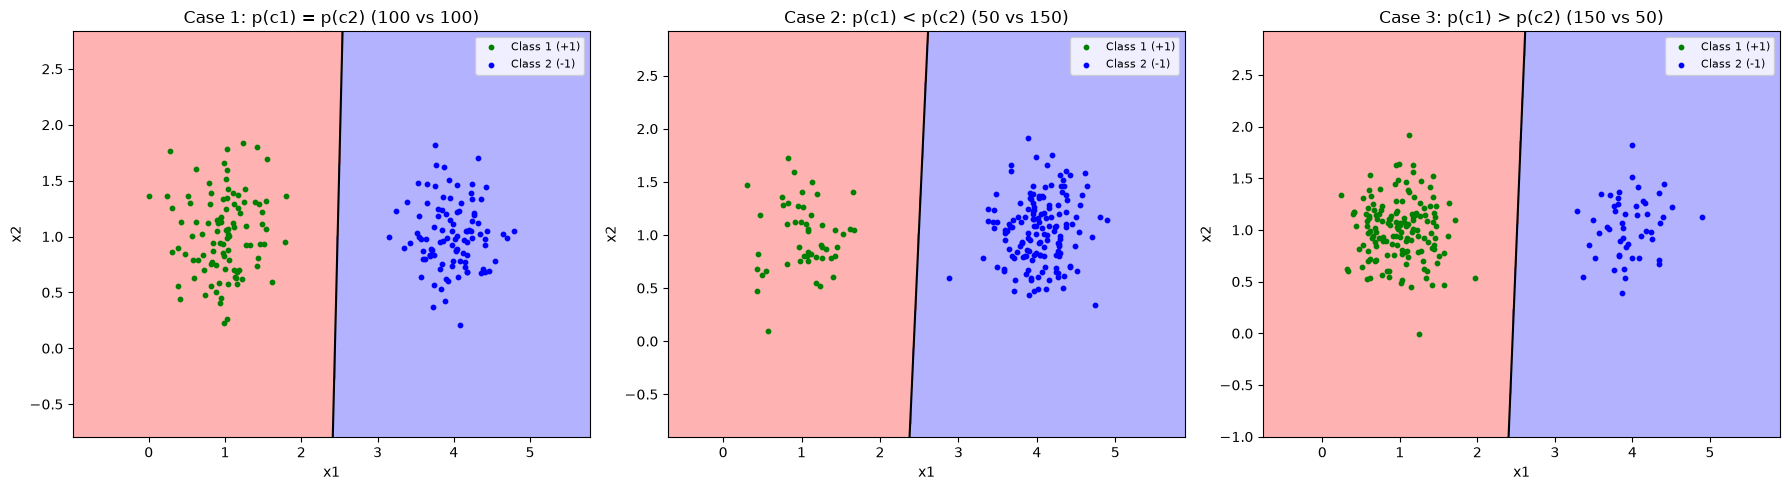

With a shared covariance matrix the decision boundary is a straight line. When the priors are unequal (p(c1) != p(c2)) the line shifts towards the class with the smaller prior, shrinking its decision region.


In [5]:
##########################################
#Part-4a)-0: Data Generation
##########################################
np.random.seed(8)
m1 = [1, 1]
m2 = [4, 1]
cov = [[0.1, 0], [0, 0.1]]

#Case1: Generate 100 samples from each class. You may use "np.random.multivariate_normal()" function to sample data points of multi-variate Gaussian distribution
class1_case1 = np.random.multivariate_normal(m1, cov, 100)
class2_case1 = np.random.multivariate_normal(m2, cov, 100)

#Case2: Generate 50 samples from class1 and 150 samples from class2. You may use "np.random.multivariate_normal()" function to sample data points of multi-variate Gaussian distribution
class1_case2 = np.random.multivariate_normal(m1, cov, 50)
class2_case2 = np.random.multivariate_normal(m2, cov, 150)

#Case3: Generate 150 samples from class1 and 50 samples from class2. You may use "np.random.multivariate_normal()" function to sample data points of multi-variate Gaussian distribution
class1_case3 = np.random.multivariate_normal(m1, cov, 150)
class2_case3 = np.random.multivariate_normal(m2, cov, 50)

##########################################
#Part-4a)-4: Plot the decision regions for all the three cases
##########################################
#Complete the below function
def decisionBoundary(X_train, Y_train):
    #Inputs: Training data and Training labels
    #Outputs: Decision boundary parameters, i.e., w0, w
    p_c1 = np.mean(Y_train == 1)
    p_c2 = 1. - p_c1

    mean_1 = np.mean(X_train[Y_train == 1], axis=0)
    mean_2 = np.mean(X_train[Y_train == -1], axis=0)

    cov1 = np.cov(X_train[Y_train == 1], rowvar=False)
    cov2 = np.cov(X_train[Y_train == -1], rowvar=False)

    #Shared covariance of the classes (pooled average of the two class covariances)
    cov = (cov1 + cov2) / 2

    #Linear decision boundary from p(c1/x) = p(c2/x):
    #w = Sigma^{-1} (m1 - m2),  w0 = -1/2 (m1^T Sigma^{-1} m1 - m2^T Sigma^{-1} m2) + ln(p_c1/p_c2)
    cov_inv = np.linalg.inv(cov)
    w = cov_inv @ (mean_1 - mean_2)
    w0 = -0.5 * (mean_1 @ cov_inv @ mean_1 - mean_2 @ cov_inv @ mean_2) + np.log(p_c1 / p_c2)

    return np.array([w0]+list(w))

#Plot the decision regions
cases_p4a = [
    ('Case 1: p(c1) = p(c2) (100 vs 100)', class1_case1, class2_case1),
    ('Case 2: p(c1) < p(c2) (50 vs 150)', class1_case2, class2_case2),
    ('Case 3: p(c1) > p(c2) (150 vs 50)', class1_case3, class2_case3),
]
plt.figure(figsize=(18, 5))
for i, (title_c, class1_c, class2_c) in enumerate(cases_p4a):
    X_c = np.vstack((class1_c, class2_c))
    Y_c = np.concatenate((np.ones(len(class1_c)), -np.ones(len(class2_c))))
    params = decisionBoundary(X_c, Y_c)
    w0_c = params[0]
    #Evaluate the boundary w^T x + w0 = 0 on a grid to visualize the regions
    x_min, x_max = X_c[:, 0].min() - 1, X_c[:, 0].max() + 1
    y_min, y_max = X_c[:, 1].min() - 1, X_c[:, 1].max() + 1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300), np.linspace(y_min, y_max, 300))
    grid_vals = params[1] * xx + params[2] * yy + w0_c
    plt.subplot(1, 3, i + 1)
    plt.contourf(xx, yy, np.sign(grid_vals), levels=[-2, 0, 2], colors=['blue', 'red'], alpha=0.3)
    plt.contour(xx, yy, grid_vals, levels=[0], colors='black')
    plt.scatter(class1_c[:, 0], class1_c[:, 1], color='green', s=10, label='Class 1 (+1)')
    plt.scatter(class2_c[:, 0], class2_c[:, 1], color='blue', s=10, label='Class 2 (-1)')
    plt.title(title_c)
    plt.xlabel('x1')
    plt.ylabel('x2')
    plt.legend(fontsize=8)
plt.tight_layout()
plt.show()
print("With a shared covariance matrix the decision boundary is a straight line. When the priors are unequal (p(c1) != p(c2)) the line shifts towards the class with the smaller prior, shrinking its decision region.")

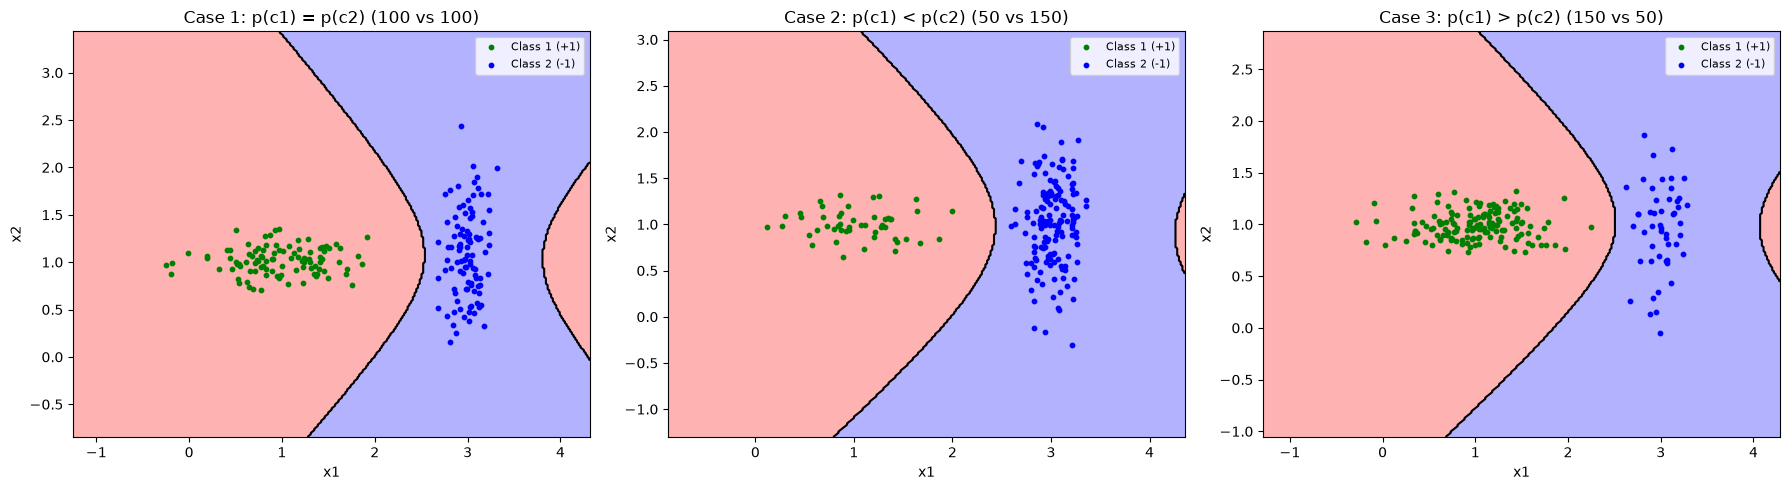

With different covariance matrices the decision boundary is non-linear (a quadratic, parabola-like curve). The unequal priors again shift the boundary towards the class with the smaller prior.


In [6]:
##########################################
#Part-4b)-0: Data Generation
##########################################
np.random.seed(9)
m1 = [1, 1]
m2 = [3, 1]
cov1 = [[0.2, 0], [0, 0.02]]
cov2 = [[0.02, 0], [0, 0.2]]

#Case1: Generate 100 samples from each class. You may use "np.random.multivariate_normal()" function to sample data points of multi-variate Gaussian distribution
class1_case1 = np.random.multivariate_normal(m1, cov1, 100)
class2_case1 = np.random.multivariate_normal(m2, cov2, 100)

#Case2: Generate 50 samples from class1 and 150 samples from class2. You may use "np.random.multivariate_normal()" function to sample data points of multi-variate Gaussian distribution
class1_case2 = np.random.multivariate_normal(m1, cov1, 50)
class2_case2 = np.random.multivariate_normal(m2, cov2, 150)

#Case3: Generate 150 samples from class1 and 50 samples from class2. You may use "np.random.multivariate_normal()" function to sample data points of multi-variate Gaussian distribution
class1_case3 = np.random.multivariate_normal(m1, cov1, 150)
class2_case3 = np.random.multivariate_normal(m2, cov2, 50)

##########################################
#Part-4b)-4: Plot the decision regions for all the three cases
##########################################
#Complete the below function
def decisionBoundary(X_train, Y_train, X_test):
    #Inputs: Training data, Training labels, and the data on which predictions are required
    #Outputs: Predictions using the quadratic (non-linear) decision boundary
    p_c1 = np.mean(Y_train == 1)
    p_c2 = 1. - p_c1

    mean_1 = np.mean(X_train[Y_train == 1], axis=0)
    mean_2 = np.mean(X_train[Y_train == -1], axis=0)

    cov1 = np.cov(X_train[Y_train == 1], rowvar=False) + 1e-9 * np.eye(2)
    cov2 = np.cov(X_train[Y_train == -1], rowvar=False) + 1e-9 * np.eye(2)

    #Quadratic discriminant of each class:
    #delta_k(x) = -1/2 ln|Sigma_k| - 1/2 (x - m_k)^T Sigma_k^{-1} (x - m_k) + ln p(c_k)
    def delta(points, mean, cov, prior):
        diff = points - mean
        cov_inv = np.linalg.inv(cov)
        _, logdet = np.linalg.slogdet(cov)
        return -0.5 * logdet - 0.5 * np.sum((diff @ cov_inv) * diff, axis=1) + np.log(prior)

    #Compute predictions on test data (assign to the class with the larger discriminant)
    points = np.asarray(X_test)
    delta1 = delta(points, mean_1, cov1, p_c1)
    delta2 = delta(points, mean_2, cov2, p_c2)
    predictions = np.where(delta1 > delta2, 1, -1)

    return predictions

#Plot the decision regions (the boundary is the locus delta_1(x) = delta_2(x))
cases_p4b = [
    ('Case 1: p(c1) = p(c2) (100 vs 100)', class1_case1, class2_case1),
    ('Case 2: p(c1) < p(c2) (50 vs 150)', class1_case2, class2_case2),
    ('Case 3: p(c1) > p(c2) (150 vs 50)', class1_case3, class2_case3),
]
plt.figure(figsize=(18, 5))
for i, (title_c, class1_c, class2_c) in enumerate(cases_p4b):
    X_c = np.vstack((class1_c, class2_c))
    Y_c = np.concatenate((np.ones(len(class1_c)), -np.ones(len(class2_c))))
    x_min, x_max = X_c[:, 0].min() - 1, X_c[:, 0].max() + 1
    y_min, y_max = X_c[:, 1].min() - 1, X_c[:, 1].max() + 1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300), np.linspace(y_min, y_max, 300))
    grid = np.c_[xx.ravel(), yy.ravel()]
    Z = decisionBoundary(X_c, Y_c, grid).reshape(xx.shape)
    plt.subplot(1, 3, i + 1)
    plt.contourf(xx, yy, Z, levels=[-2, 0, 2], colors=['blue', 'red'], alpha=0.3)
    plt.contour(xx, yy, Z, levels=[0], colors='black')
    plt.scatter(class1_c[:, 0], class1_c[:, 1], color='green', s=10, label='Class 1 (+1)')
    plt.scatter(class2_c[:, 0], class2_c[:, 1], color='blue', s=10, label='Class 2 (-1)')
    plt.title(title_c)
    plt.xlabel('x1')
    plt.ylabel('x2')
    plt.legend(fontsize=8)
plt.tight_layout()
plt.show()
print("With different covariance matrices the decision boundary is non-linear (a quadratic, parabola-like curve). The unequal priors again shift the boundary towards the class with the smaller prior.")

<b> Report your observations </b>

1. When the two class distributions share the same covariance matrix, the MAP decision boundary is linear (a straight line), independent of the class priors except for a shift.

2. When the class distributions have different covariance matrices, the decision boundary becomes non-linear (a quadratic curve); here, with Sigma_1 elongated along x and Sigma_2 along y, the boundary is a parabola-like curve that wraps around the class with the smaller spread.

3. The class priors strongly influence the boundary: with p(c1) < p(c2) the boundary shifts towards class 1 (shrinking its region) and with p(c1) > p(c2) it shifts towards class 2, since the MAP rule multiplies the likelihoods by the priors.

<b> Part-5) Classification using logistic regression ( Iterative reweighted least squares approach ): </b> logistic regression model: $y = \frac{1}{1+e^{-\textbf{w}^{T}\textbf{x}}}$. With the provided training data, X_train and Y_train, your task is to identify the optimal $\textbf{w}$ that accurately predicts y based on the input $\textbf{x}$. Subsequently, this $\textbf{w}$ can be applied to predict outcomes on the test data, X_test.





a). Data generation: Consider a classification scenario with two classes. Class 1 follows a Gaussian distribution with a mean vector $\begin{bmatrix} 1  \\ 1  \end{bmatrix}$ and a covariance matrix $\begin{bmatrix} 0.3 & 0.0  \\ 0.0 & 0.3 \end{bmatrix}$. Class 2 follows a Gaussian distribution with a mean vector $\begin{bmatrix} 2  \\ 2  \end{bmatrix}$ and a covariance matrix $\begin{bmatrix} 0.3 & 0.0  \\ 0.0 & 0.3 \end{bmatrix}$. Employ these class distributions to generate 50 samples per class for training and 200 samples for testing.

b). Create a function called "Logistic_Regression" that accepts training data, training labels, and testing data as inputs. The function should aim to discover the optimal $\textbf{w}$ using the training data. You can initialize $\textbf{w}$ with random values and iteratively update it to determine the optimal $\textbf{w}$. Subsequently, this optimal $\textbf{w}$ can be employed to make predictions on the test data.

c). Evaluate the classification performance, i.e., compute the accuracy on the test data.

d). Write a function to generate & visualize the decision regions, either by showing the boundary line or by using different colors for the two regions. Overlay the test points using scatter.

e). Introduce genuine outliers to one of the class datasets generated previously. Then, conduct Least Squares classification and Logistic Regression on this modified dataset. Plot the decision boundaries/regions and provide insights into the differences between their outcomes.


f). Report your observations




 Accuracy with Logistic Regression: 0.895 




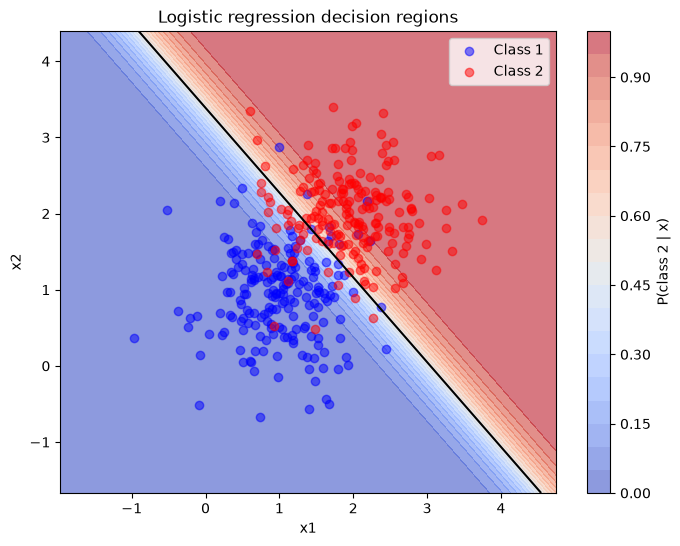

Accuracy with least squares (with outliers): 90.50%
Accuracy with logistic regression (with outliers): 89.50%


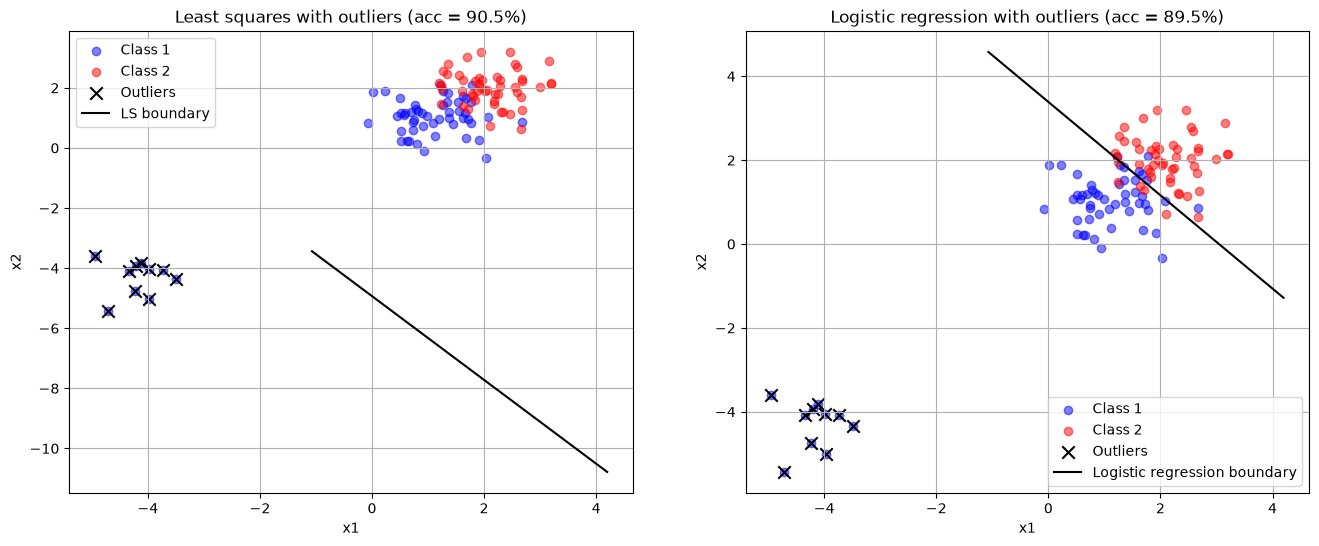

Comparison: the least squares boundary is pulled strongly towards the outliers (the squared error grows quadratically with the distance of a point from the boundary), degrading its accuracy. The logistic regression boundary is much less affected because the sigmoid saturates for far away points, so their contribution to the gradient vanishes once they lie on the correct side of the boundary.


In [7]:
##################################################
#Part-5)-1: Data generation
##################################################

#Set the parameters of class distribution
mean1 = [1, 1]              #Mean of class1
mean2 = [2, 2]              #Mean of class2
cov = [[0.3, 0], [0, 0.3]]  #Covariance matrix. Same covariance for class1 and class2

#Generate training data. You can use "np.random.multivariate_normal()" function to sample data points from multivariate Gaussian distribution
class1_tr = np.random.multivariate_normal(mean1, cov, 50)   #Class1 training data
class2_tr = np.random.multivariate_normal(mean2, cov, 50)   #Class2 training data
tr_data = np.concatenate((class1_tr, class2_tr), axis=0)                 #Combine class1 training and class2 training data to get total training data
tr_targets = np.concatenate((np.zeros(50), np.ones(50)))              #Class labels. Assign the value "0" to class1 and the value "1" to class2.

#Generate testing data.
class1_te = np.random.multivariate_normal(mean1, cov, 200)   #Class1 testing data
class2_te = np.random.multivariate_normal(mean2, cov, 200)   #Class2 testing data
te_data = np.concatenate((class1_te, class2_te), axis=0)                 #Combine class1 testing and class2 testing data to get total testing data
te_targets = np.concatenate((np.zeros(200), np.ones(200)))            #Class labels. Assign the value "0" to class1 and the value "1" to class2.


##################################################
#Part-5)-b: Complete the below logistic regression function
##################################################
def sigmoid(z):
    z = np.clip(z, -500, 500)
    return 1 / (1 + np.exp(-z))

def Logistic_Regression(X_train, Y_train, X_test):
  #Inputs: Training data, Training labels, and Testing data
  #Outputs: Predictions on test data

  max_iter = 100  #max number of ierations for parameter update
  threshold = 0.5 #threshold for classification
  X = np.hstack((np.ones((len(X_train), 1)), X_train))          #Data. Append ones to the training data to take care of the bias
  w = np.zeros(X.shape[1])          #Initialize the weight vector
  for iter in range(0,max_iter,1):
    preds = sigmoid(X @ w)      #Predictions on X. Sigmoid(w^T.x)
    error = preds - Y_train     #Difference between preds and Y_train

    #Compute the gradients and the appropriate learning rate. We can use Hessian matrix as learning rate
    #Newton-Raphson / iterative reweighted least squares update:
    #gradient = X^T (preds - t),  Hessian = X^T R X with R = diag(preds * (1 - preds))
    R = preds * (1 - preds)
    H = X.T @ (R[:, None] * X)
    gradient = X.T @ error

    #Update the weight vector
    w = w - np.linalg.pinv(H) @ gradient

  #Test data predictions
  X_test_aug = np.hstack((np.ones((len(X_test), 1)), X_test))
  test_probs = sigmoid(X_test_aug @ w)

  #Compare the predictions with 0, to output the decision
  test_preds = np.where(test_probs > threshold, 1, 0)

  #Return the predicted test labels
  return test_preds, w


Y_pred, w_lr = Logistic_Regression(tr_data, tr_targets, te_data)

###############################################
#Part-5)-c:
###############################################
def LR_Accuracy(Y_test, Y_pred):
  #Inputs: Ground truth and predicted lables of test data
  #Outputs: Accuracy

  #Compute and return the accuracy
  acc = np.mean(Y_test == Y_pred)
  return acc


acc = LR_Accuracy(te_targets, Y_pred)
print('\n\n Accuracy with Logistic Regression:', acc, '\n\n')


##########################################
#Part-5)-d: Plot the decision regions. Overlay the test points on the plot
##########################################
plt.figure(figsize=(8, 6))
x_min, x_max = te_data[:, 0].min() - 1, te_data[:, 0].max() + 1
y_min, y_max = te_data[:, 1].min() - 1, te_data[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300), np.linspace(y_min, y_max, 300))
grid_aug = np.hstack((np.ones((xx.ravel().shape[0], 1)), np.c_[xx.ravel(), yy.ravel()]))
grid_probs = sigmoid(grid_aug @ w_lr).reshape(xx.shape)
plt.contourf(xx, yy, grid_probs, levels=20, cmap='coolwarm', alpha=0.6)
plt.colorbar(label='P(class 2 | x)')
plt.contour(xx, yy, grid_probs, levels=[0.5], colors='black')
plt.scatter(te_data[te_targets == 0][:, 0], te_data[te_targets == 0][:, 1], color='blue', label='Class 1', alpha=0.5)
plt.scatter(te_data[te_targets == 1][:, 0], te_data[te_targets == 1][:, 1], color='red', label='Class 2', alpha=0.5)
plt.xlabel('x1')
plt.ylabel('x2')
plt.title('Logistic regression decision regions')
plt.legend()
plt.show()

##########################################
#Part-5)-e: Logistic regression for the data with true outliers
##########################################
#Add 10 true outliers to class 1 (sampled from a distribution far away from the class means)
outliers_lr = np.random.multivariate_normal([-4, -4], [[0.3, 0], [0, 0.3]], 10)   #far away from both class means, on the class 1 side
tr_data_out = np.concatenate((tr_data, outliers_lr), axis=0)
tr_targets_out = np.concatenate((tr_targets, np.zeros(10)))

#Least squares classification on the modified data (using LS_Classify from Part-1)
pred_ls_out, w_ls_out = LS_Classify(tr_data_out, tr_targets_out, te_data)
acc_ls_out = LS_Classify_Accuracy(te_targets, pred_ls_out)

#Logistic regression on the modified data
Y_pred_out, w_lr_out = Logistic_Regression(tr_data_out, tr_targets_out, te_data)
acc_lr_out = LR_Accuracy(te_targets, Y_pred_out)

print(f'Accuracy with least squares (with outliers): {acc_ls_out * 100:.2f}%')
print(f'Accuracy with logistic regression (with outliers): {acc_lr_out * 100:.2f}%')

plt.figure(figsize=(16, 6))
x_vals = np.linspace(tr_data[:, 0].min() - 1, max(tr_data[:, 0].max(), outliers_lr[:, 0].max()) + 1, 100)
plt.subplot(121)
plt.scatter(tr_data_out[tr_targets_out == 0][:, 0], tr_data_out[tr_targets_out == 0][:, 1], color='blue', label='Class 1', alpha=0.5)
plt.scatter(tr_data_out[tr_targets_out == 1][:, 0], tr_data_out[tr_targets_out == 1][:, 1], color='red', label='Class 2', alpha=0.5)
plt.scatter(outliers_lr[:, 0], outliers_lr[:, 1], color='black', marker='x', s=80, label='Outliers')
y_vals = -(w_ls_out[0] + w_ls_out[1] * x_vals) / w_ls_out[2]
plt.plot(x_vals, y_vals, color='black', label='LS boundary')
plt.xlabel('x1')
plt.ylabel('x2')
plt.title(f'Least squares with outliers (acc = {acc_ls_out * 100:.1f}%)')
plt.legend()
plt.grid(True)
plt.subplot(122)
plt.scatter(tr_data_out[tr_targets_out == 0][:, 0], tr_data_out[tr_targets_out == 0][:, 1], color='blue', label='Class 1', alpha=0.5)
plt.scatter(tr_data_out[tr_targets_out == 1][:, 0], tr_data_out[tr_targets_out == 1][:, 1], color='red', label='Class 2', alpha=0.5)
plt.scatter(outliers_lr[:, 0], outliers_lr[:, 1], color='black', marker='x', s=80, label='Outliers')
y_vals = -(w_lr_out[0] + w_lr_out[1] * x_vals) / w_lr_out[2]
plt.plot(x_vals, y_vals, color='black', label='Logistic regression boundary')
plt.xlabel('x1')
plt.ylabel('x2')
plt.title(f'Logistic regression with outliers (acc = {acc_lr_out * 100:.1f}%)')
plt.legend()
plt.grid(True)
plt.show()
print("Comparison: the least squares boundary is pulled strongly towards the outliers (the squared error grows quadratically with the distance of a point from the boundary), degrading its accuracy. The logistic regression boundary is much less affected because the sigmoid saturates for far away points, so their contribution to the gradient vanishes once they lie on the correct side of the boundary.")

<b> Part (6) : Estimating the parameters of Gaussian Mixture Models (GMM) using Expectation-Maximization (EM) algorithm </b>


<dt> <b> a. Generating synthetic data : </b>  This part describes the steps involved in generating the synthetic data. </dt>


<dt>  1. Let us consider the GMM with Bivariate Gaussians   </dt>
<dd>  - Choose the appropriate means ($\mu$), covariances ($\Sigma$), and weights ($\pi$) of Bivariate Gaussian distributions. You may choose the following parameters for this asignment.  </dd>
<br>
<dt>  <center> $ \pi = \begin{bmatrix} 0.6  \\ 0.4 \end{bmatrix} \;\;\;\; \mu_{1} = \begin{bmatrix} -1.0  \\ -1.0 \end{bmatrix} \;\;\;\; \mu_{2} = \begin{bmatrix} 1.0  \\ 1.0 \end{bmatrix} \;\;\;\; $ </center>   </dd>
<br>
<dt>  <center> $ \Sigma_{1}^{full} = \begin{bmatrix} 0.15 & 0.1  \\ 0.1 & 0.25 \end{bmatrix} \;\;\;\; \Sigma_{2}^{full} = \begin{bmatrix} 0.3 & -0.25  \\ -0.25 & 0.25 \end{bmatrix}  $ </center>  </dd>
<br>
<dt>  <center> $ \Sigma_{1}^{diagonal} = \begin{bmatrix} 0.1 & 0.0  \\ 0.0 & 0.2 \end{bmatrix} \;\;\;\; \Sigma_{2}^{diagonal} = \begin{bmatrix} 0.2 & 0.0  \\ 0.0 & 0.1 \end{bmatrix}  $ </center>  </dd>
<br>
<dt>  <center> $ \Sigma_{1}^{spherical} = \begin{bmatrix} 0.2 & 0.0  \\ 0.0 & 0.2 \end{bmatrix} \;\;\;\; \Sigma_{2}^{spherical} = \begin{bmatrix} 0.1 & 0.0  \\ 0.0 & 0.1 \end{bmatrix}  $ </center>  </dd>

<dd>  - Pick one Gaussian following the selection probability as  $\pi$    </dd>
<dd>  - Sample the data point from the selected Bivariate Gaussian distribution    </dd>
<dd>  - Repeat the process N times to get the entire data set  </dd>
<dt>  2.Create the synthetic data set with the number of mixtures as 2.  </dt>
<dt>  3.Plot the synthetic data set with unique colors to the data points drawn from each Bivariate Gaussian distribution in GMM  </h4> </dt> </dd>

<dt> <b> b. Implementation of Expectation and Maximization (EM) algorithm : </b> This part focuses on implementing the EM algorithm from scratch to estimate the parameters of the Gaussian Mixture Model (GMM). </dt>  

<dt>  1. Chose the number of mixtures (M) and initialize the parameters of GMM model  </dt>
<dd>  - Make sure that the diagonal elements of covariance are positive, and the weights of Gaussians are positive and sum to 1 for satisfying the axioms of probability.  </dd>

<dt>   2. Expectation step :  Evaluate the responsibility of Gaussians in generating the data points using the current estimated parameters i.e $\hat\mu_{k}$ , $\hat\Sigma_{k}$ and $\hat\pi_{k}$, here k indicates the Gaussian in GMM  </dt>
<br>

<dd>  <center> $\gamma_{nk} = \frac{\pi_{k} N ( \textbf{x}_{n} / \mu_{k} , \Sigma_{k} )}{ \sum_{m=1}^{M} \pi_{m} N ( x_{n} / \mu_{m} , \Sigma_{m} ) }    \;\;\;\;\;\; ∀ \;\;k=1,2,...,M \;\; and \;\; n=1,2,...,N$  </center>  </dd>

<br>

<dd>   Where N is the total number of data points and M is the total number of Gaussians in GMM   </dd>

<dd>   - $\gamma_{nk}$ represents the responsibility of $k^{th}$ Gaussian in generating the $n^{th}$ data point   </dd>

<dd>   - $\sum_{n=1}^{N}$ $\gamma_{nk}$ represents the the effective number of data points generated by $k^{th}$ Gaussian   </dd>


<dt>   3. Maximization step :  Update the parameters ($\hat\mu_{k}$ , $\hat\Sigma_{k}$ and $\hat\pi_{k}$) of GMM using the current resosibilities ($\gamma_{nk}$) by maximizing the likelihood. </dt>

<dd>
 - Effective number of data points generated by $k^{th}$ Gaussian : $N_{k}$ = $\sum_{n=1}^{N}$ $\gamma_{nk}$   
 </dd>

<dd>
 - Mean of $k^{th}$ Gaussian : $\hat{\mu_{k}} = \frac{1}{N_{k}} \sum_{n=1}^{N}\gamma_{nk} x_{n}$   
 </dd>

<dd>
 - Covariance of $k^{th}$ Gaussian : $\hat{\Sigma_{k}} = \frac{1}{N_{k}} \sum_{n=1}^{N} \gamma_{nk} ( x_{n} - \hat{\mu_{k}} )( x_{n} - \hat{\mu_{k}} )^{T}$   
 </dd>

<dd>
 - Weight of $k^{th}$ Gaussian : $\hat{\pi_{k}} = \frac{N_{k}}{N}$  
 </dd>

<dt>  4. Compute the log-likelihood with the updated parameters  </dt>
<dt>   5. Repeat the expectation and maximization steps untill convergence  </dt>

<dt>  <b> c. Illustration of EM iterations </b>  </dt>

<dt>   5. Plot the contours of the estimated distributions over the iterations in the EM algorithm and overlay the data points.  </dt>

<dt>  <b> d. Understanding the issues with EM algorithm </b>  </dt>
<dt>   6. Check the influence of initialization on the convergence of the EM algorithm and fit quality.  </dt>
<dd>   - Demonstrate the observations with the plots mentioned in the "Illustration of EM iterations" section    </dd>
<dt>   6. Check the influence of the type of covariance matrix on the convergence of the EM algorithm and fit quality . </dt>
<dd>   - Execute the EM algorithm with different covariance matrices i.e Spherical, Diagonal and Full covariance  </dd>
<dd>   - Demonstrate the observations with the plots mentioned in the "Illustration of EM iterations" section  </dd>


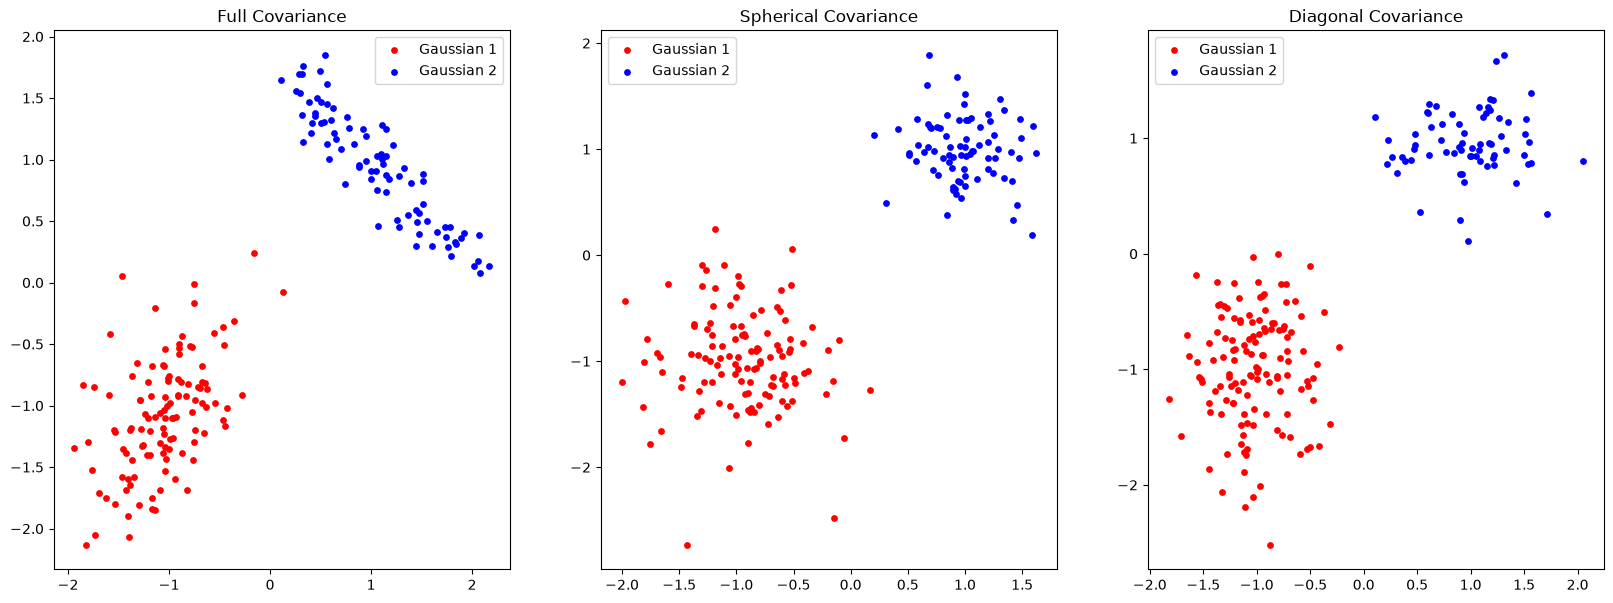

In [8]:
#All imports
import numpy as np
import pandas as pd
import random as rand
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from scipy.stats import norm, multivariate_normal
import sys
import math

##########################################
#Part-6)-a: Generating synthetic data
##########################################

def generateData(pi, mu, sigma, N):
    ############################################################################
    #pi = weights of Gaussians, mu = mean of Gaussians, sigma = convariance of Gaussians, N = number of data points
    #Steps
    #1.Select th Gaussian following the probability distribution as pi
    #2.Sample the data points from the selected Gaussian
    #3.Repeat the process N times to get N data points
    #4.Return the sampled data
    ############################################################################
    #You may look into "random.choices" and "np.random.multivariate_normal" functions
    data = []
    labels = []
    for _ in range(N):
        #1.Select the Gaussian following the selection probability as pi
        k = np.random.choice(len(pi), p=pi)
        #2.Sample the data point from the selected Bivariate Gaussian distribution
        sample = np.random.multivariate_normal(mu[k], sigma[k])
        data.append(sample)
        labels.append(k)

    return np.asarray(data), np.asarray(labels)
    ############################################################################


############################################################################
#Chose the appropriate means ($\mu$), covariances ($\Sigma$), and weights
############################################################################
mu1 = [-1.0, -1.0]                    #Mean vector of component1 in GMM
sig1 = [[0.15, 0.1], [0.1, 0.25]]     #Full covariance matrix of component1 in GMM
mu2 = [1.0, 1.0]                      #Mean vector of component2 in GMM
sig2 = [[0.3, -0.25], [-0.25, 0.25]]  #Full covariance matrix of component2 in GMM
pi = [0.6, 0.4]                       #Prior probabilities

n_points = 200   #Number of points

# Spherical covariances
sig1_s = [[0.2, 0], [0, 0.2]]
sig2_s = [[0.1, 0], [0, 0.1]]
# Diagonal covariances
sig1_d = [[0.1, 0], [0, 0.2]]
sig2_d = [[0.2, 0], [0, 0.1]]

############################################################################
#Create the synthetic data set
############################################################################

data_full, labels_full = generateData(pi, [mu1, mu2], [sig1, sig2], 200)
data_sp, labels_sp = generateData(pi, [mu1, mu2], [sig1_s, sig2_s], 200)
data_dg, labels_dg = generateData(pi, [mu1, mu2], [sig1_d, sig2_d], 200)

############################################################################
#Plot the synthetic data set
############################################################################

fig, ax = plt.subplots(1,3, figsize=(20,7))

#Visualize the data sampled from the GMM with full covariance matrix
ax[0].set_title('Full Covariance')
ax[0].scatter(data_full[labels_full == 0][:, 0], data_full[labels_full == 0][:, 1], color='red', s=15, label='Gaussian 1')
ax[0].scatter(data_full[labels_full == 1][:, 0], data_full[labels_full == 1][:, 1], color='blue', s=15, label='Gaussian 2')
ax[0].legend()

#Visualize the data sampled from the GMM with spherical covariance matrix
ax[1].set_title('Spherical Covariance')
ax[1].scatter(data_sp[labels_sp == 0][:, 0], data_sp[labels_sp == 0][:, 1], color='red', s=15, label='Gaussian 1')
ax[1].scatter(data_sp[labels_sp == 1][:, 0], data_sp[labels_sp == 1][:, 1], color='blue', s=15, label='Gaussian 2')
ax[1].legend()

#Visualize the data sampled from the GMM with diagonal covariance matrix
ax[2].set_title('Diagonal Covariance')
ax[2].scatter(data_dg[labels_dg == 0][:, 0], data_dg[labels_dg == 0][:, 1], color='red', s=15, label='Gaussian 1')
ax[2].scatter(data_dg[labels_dg == 1][:, 0], data_dg[labels_dg == 1][:, 1], color='blue', s=15, label='Gaussian 2')
ax[2].legend()

plt.show()

Iteration 1: log-likelihood = -588.5064


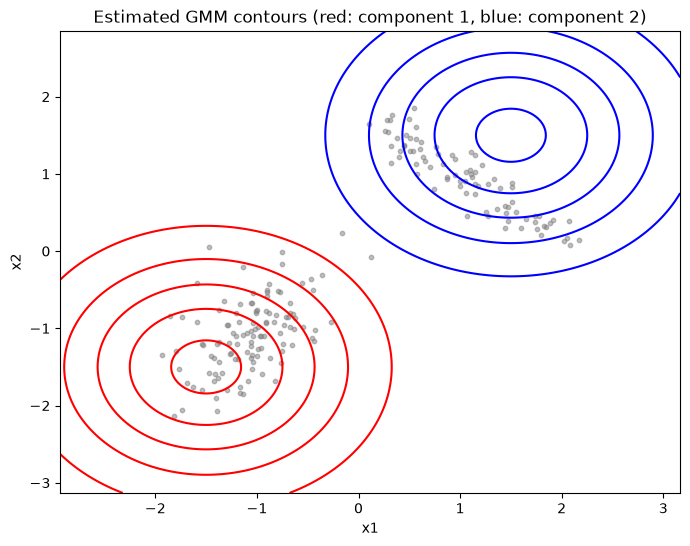

Iteration 2: log-likelihood = -323.3184


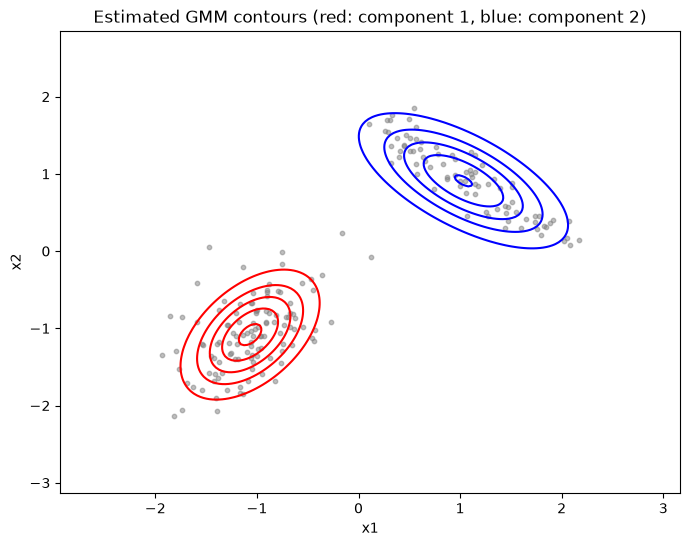

Iteration 3: log-likelihood = -291.8277


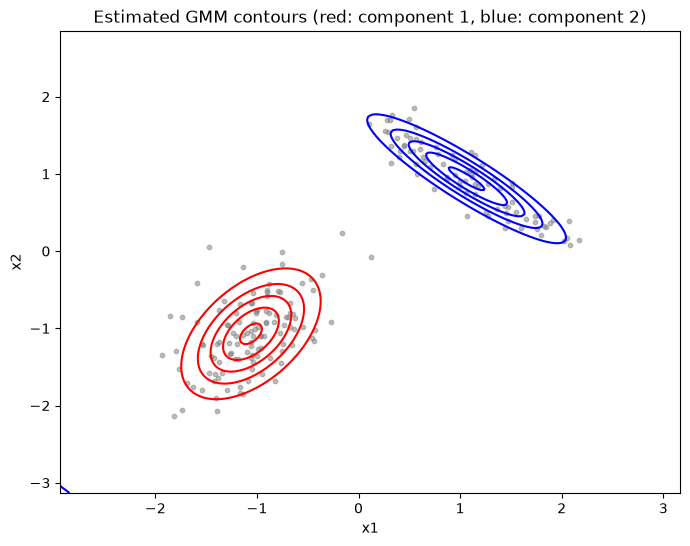

Iteration 4: log-likelihood = -291.8219


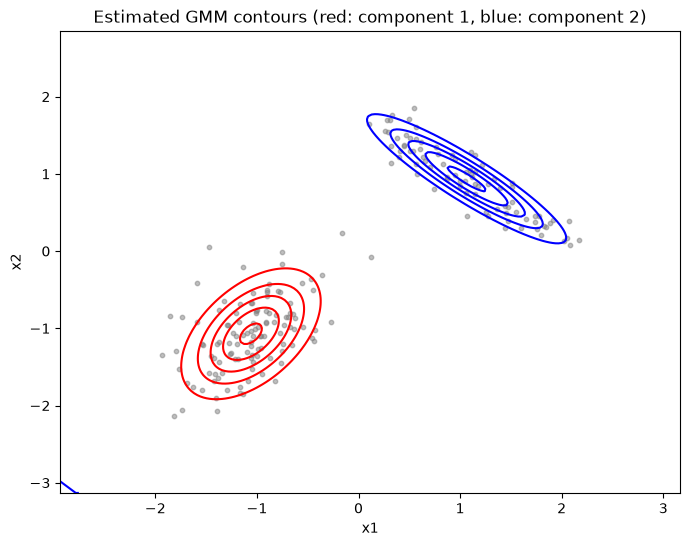

Iteration 5: log-likelihood = -291.8219


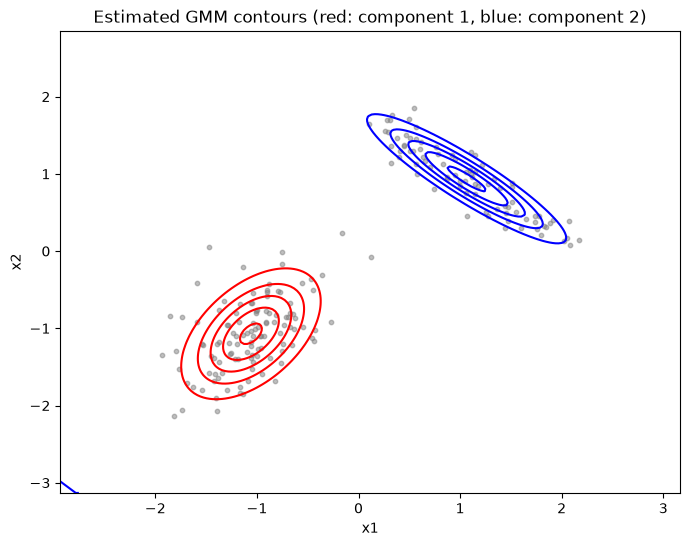

Iteration 6: log-likelihood = -291.8219


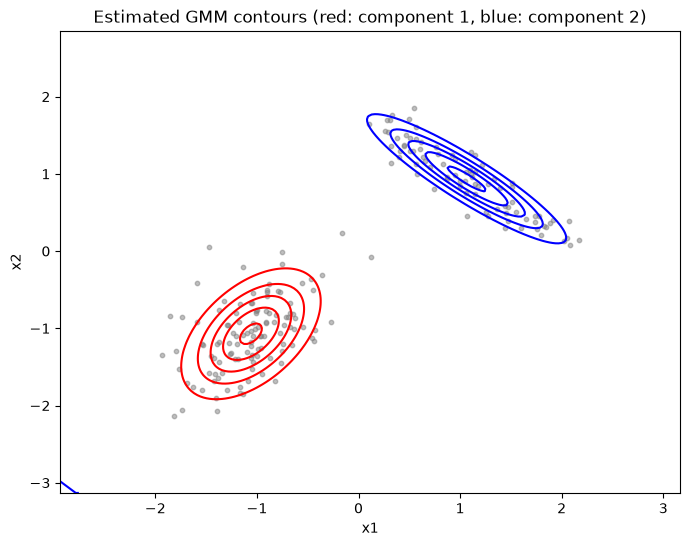

Iteration 7: log-likelihood = -291.8219


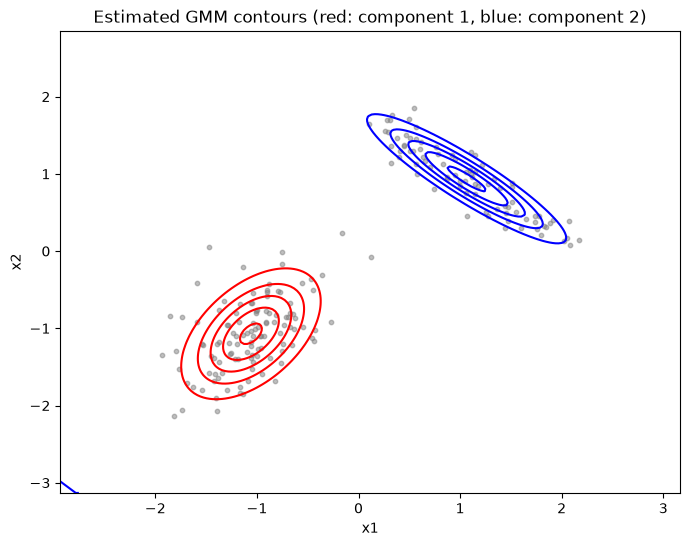

Iteration 8: log-likelihood = -291.8219


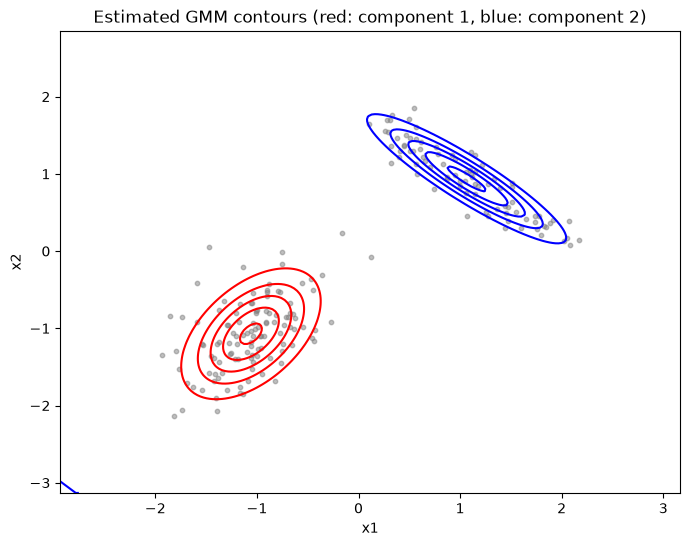

Iteration 9: log-likelihood = -291.8219

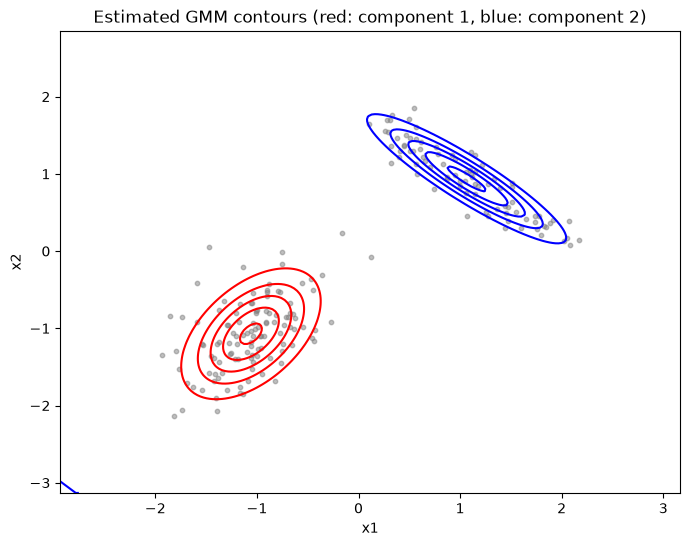

Iteration 10: log-likelihood = -291.8219


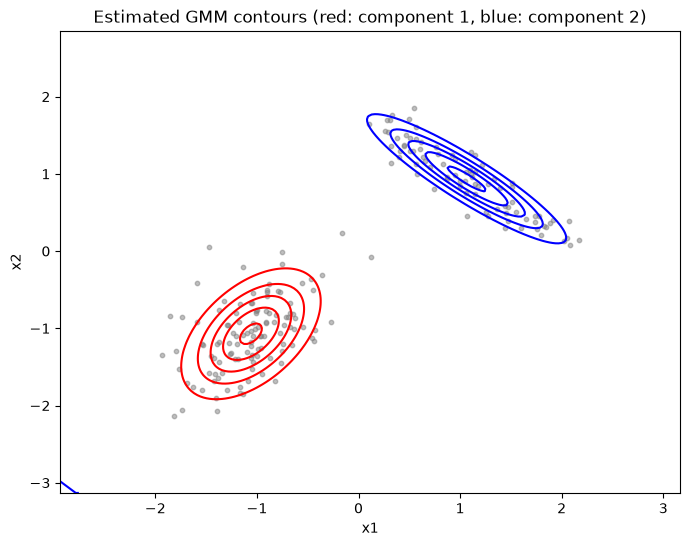

Estimated pi: [0.58000067 0.41999933]
Estimated mu:
[[-1.05868202 -1.07101365]
 [ 1.06409877  0.93653938]]
Estimated sigma:
[[[ 0.14269673  0.08778227]
  [ 0.08778227  0.21741216]]

 [[ 0.28744846 -0.22422159]
  [-0.22422159  0.20936183]]]


In [9]:
#All imports
import numpy as np
import pandas as pd
import random as rand
import matplotlib.pyplot as plt
from scipy.stats import norm, multivariate_normal
import sys
import math

##########################################
#Part-6)-b: Implimentation of Expectation-Maximization (EM) algorithm
##########################################

############################################################################
#Write a function to compute the log-likelihood of the data given the parameters
############################################################################
def likelihood(data, pi, mu, sigma, log_likelihood=False, likelihoods=False):
  #Inputs: data, parameters of GMM model
  #Outputs: likelihood
  N = len(data)
  M = len(pi)
  probs = np.zeros((N, M))
  for k in range(M):
      probs[:, k] = pi[k] * multivariate_normal.pdf(data, mean=mu[k], cov=sigma[k])
  if likelihoods:
      return probs
  total_log_likelihood = np.sum(np.log(np.sum(probs, axis=1) + 1e-300))
  if log_likelihood:
      return total_log_likelihood
  return np.exp(total_log_likelihood)


############################################################################
#Write a function for the expectation step
############################################################################
def expectation(data, pi, mu, sigma):
  #Inputs: data, parameters of GMM model
  #Outputs: gamma
  gamma = np.zeros((len(data), len(pi)))
  for n in range(len(data)):
    #Iterate through the data points
    for k in range(len(pi)):
      #Iterate through the components in GMM
      numerator = pi[k] * multivariate_normal.pdf(data[n], mean=mu[k], cov=sigma[k])
      denominator = np.sum([pi[m] * multivariate_normal.pdf(data[n], mean=mu[m], cov=sigma[m]) for m in range(len(pi))])
      gamma[n,k] = numerator/denominator
  return gamma



############################################################################
#Write a function for the maximization step.
############################################################################
def maximization(data, gamma):
  #Inputs: data, gamma
  #Outputs: Updated parameters of GMM model
  N = len(data)
  D = data.shape[1]
  M = gamma.shape[1]
  mu = np.zeros((M, D))
  sigma = np.zeros((M, D, D))
  pi = np.zeros(M)
  for k in range(M):
      #Effective number of data points generated by the k-th Gaussian
      N_k = np.sum(gamma[:, k])
      #Update mu
      mu[k] = np.sum(gamma[:, k].reshape(-1, 1) * data, axis=0) / N_k
      #Update sigma
      diff = data - mu[k]
      sigma[k] = (gamma[:, k].reshape(-1, 1) * diff).T @ diff / N_k
      #Update pi
      pi[k] = N_k / N

  #Return the parameters of GMM model
  return pi, mu, sigma


#Complete the below function. It plots the contours
def plot_contours(data, labels, pi, mu, sigma):
  #Plot the contours of the estimated GMM components and overlay the data points
  plt.figure(figsize=(8, 6))
  plt.scatter(data[:, 0], data[:, 1], s=10, color='gray', alpha=0.5)
  x_min, x_max = data[:, 0].min() - 1, data[:, 0].max() + 1
  y_min, y_max = data[:, 1].min() - 1, data[:, 1].max() + 1
  xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200), np.linspace(y_min, y_max, 200))
  grid = np.c_[xx.ravel(), yy.ravel()]
  colors = ['red', 'blue']
  for k in range(len(pi)):
      Z = multivariate_normal.pdf(grid, mean=mu[k], cov=sigma[k]).reshape(xx.shape)
      plt.contour(xx, yy, Z, levels=5, colors=colors[k % len(colors)])
  plt.title('Estimated GMM contours (red: component 1, blue: component 2)')
  plt.xlabel('x1')
  plt.ylabel('x2')
  plt.show()



############################################################################
#Run the expectation and maximzation algorithm to estimate the parameters
############################################################################
data = data_full            #data to run EM-algorithm
labels = labels_full        #labels
N = len(data)               #number of input examples
D = data.shape[1]           #data dimension
M = 2                       #no.of components in GMM

pi = np.array([0.5, 0.5])                                                #Initialize the prior probabilities
mu = np.array([[-1.5, -1.5], [1.5, 1.5]])                                #Initialize the mean vectors
sigma = np.array([[[1.0, 0.0], [0.0, 1.0]], [[1.0, 0.0], [0.0, 1.0]]])   #Initialize the covariance matrices


nsteps = 10   #Number of steps to run EM algorithm
for index in range(0,nsteps,1):

  #Compute the likelihood
  ll = likelihood(data, pi, mu, sigma, log_likelihood=True)
  print(f"Iteration {index + 1}: log-likelihood = {ll:.4f}")

  #Plot the contours
  plot_contours(data, labels, pi, mu, sigma)

  #Expectation step
  gamma = expectation(data, pi, mu, sigma)

  #Maximization step
  pi, mu, sigma = maximization(data, gamma)

print("Estimated pi:", pi)
print("Estimated mu:")
print(mu)
print("Estimated sigma:")
print(sigma)

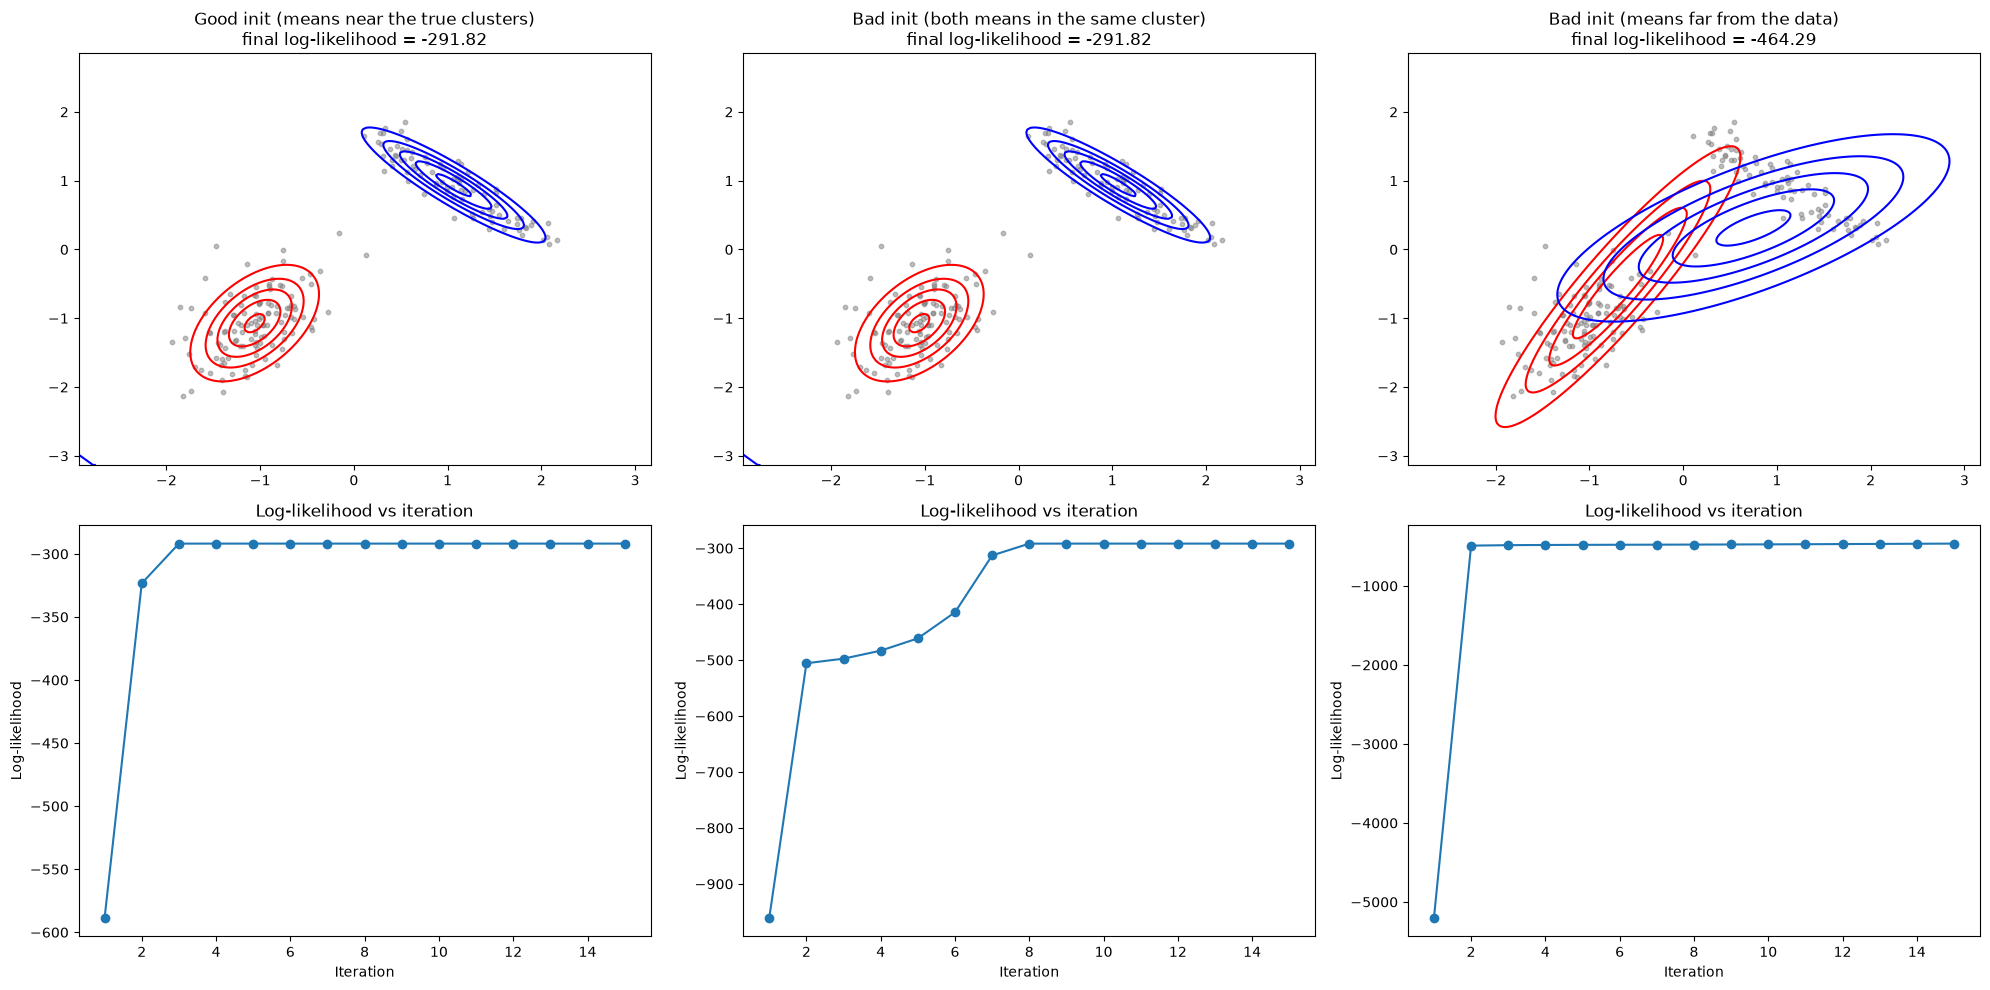

Influence of initialization: with a good initialization EM converges to the true clusters with a high log-likelihood. With a bad initialization (both means in the same cluster) the two components can stay tied to a single cluster (symmetric responsibilities), giving a lower log-likelihood. With means far from the data the initial responsibilities are almost uniform and convergence is slower; EM may get stuck in a poor local optimum, which is why multiple random restarts are commonly used.


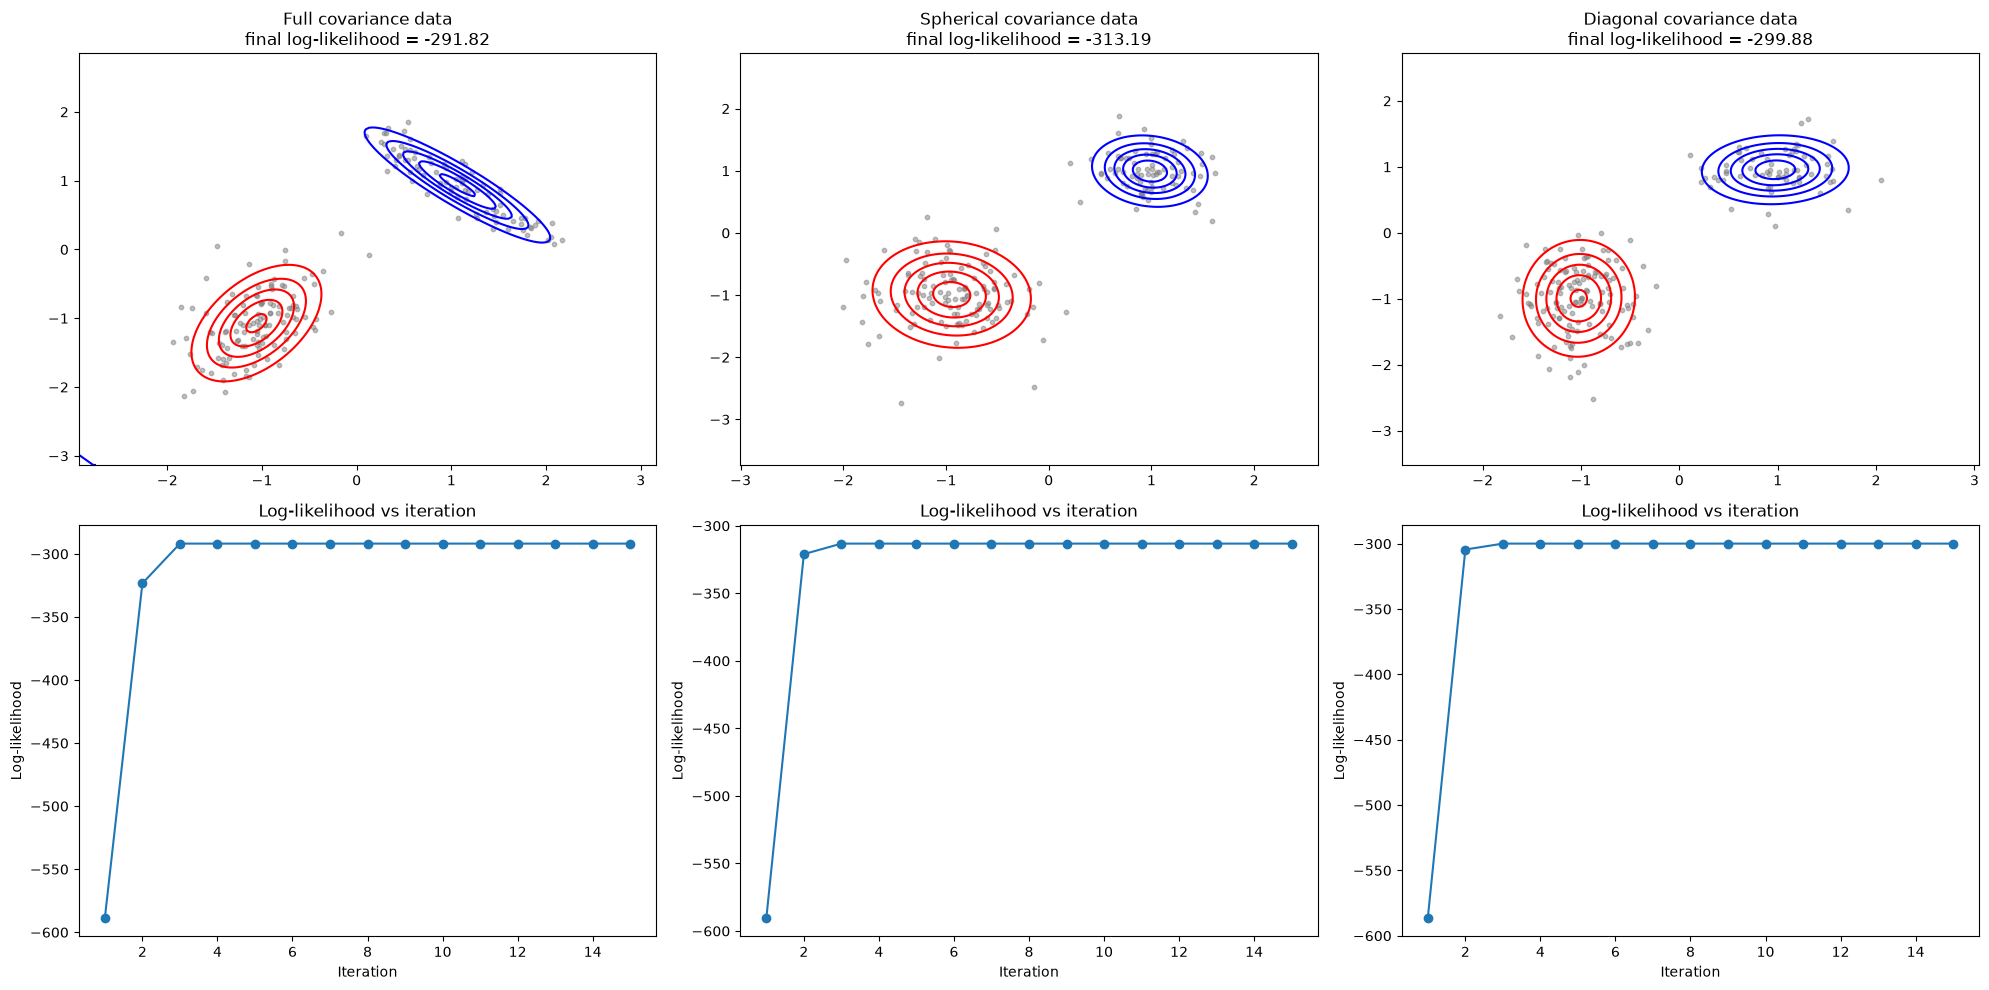

Influence of the covariance type: the full covariance model fits elongated, correlated clusters and achieves the highest log-likelihood on the full-covariance data; the spherical model (a single variance per component) can only fit circular clusters and underfits correlated data; the diagonal model is in between. On the spherical data all three models converge similarly since the clusters are circular.


In [10]:
############################################################################
##Part-6)-d: Understand the issues with EM algorithm
############################################################################

#1. Check the influence of initialization on the convergence of the EM algorithm and fit quality
initializations = [
    ('Good init (means near the true clusters)', np.array([[-1.5, -1.5], [1.5, 1.5]])),
    ('Bad init (both means in the same cluster)', np.array([[1.0, 1.0], [1.3, 1.3]])),
    ('Bad init (means far from the data)', np.array([[-5.0, 5.0], [5.0, -5.0]])),
]

fig, axes = plt.subplots(2, 3, figsize=(20, 10))
x_min, x_max = data[:, 0].min() - 1, data[:, 0].max() + 1
y_min, y_max = data[:, 1].min() - 1, data[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200), np.linspace(y_min, y_max, 200))
grid = np.c_[xx.ravel(), yy.ravel()]

for col, (name, mu_init) in enumerate(initializations):
    pi_i = np.array([0.5, 0.5])
    mu_i = mu_init.copy()
    sigma_i = np.array([[[1.0, 0.0], [0.0, 1.0]], [[1.0, 0.0], [0.0, 1.0]]])
    lls = []
    for step in range(15):
        lls.append(likelihood(data, pi_i, mu_i, sigma_i, log_likelihood=True))
        gamma_i = expectation(data, pi_i, mu_i, sigma_i)
        pi_i, mu_i, sigma_i = maximization(data, gamma_i)
    #Plot the final contours over the data
    ax = axes[0, col]
    ax.scatter(data[:, 0], data[:, 1], s=10, color='gray', alpha=0.5)
    for k in range(2):
        Z = multivariate_normal.pdf(grid, mean=mu_i[k], cov=sigma_i[k]).reshape(xx.shape)
        ax.contour(xx, yy, Z, levels=5, colors=['red', 'blue'][k])
    ax.set_title(f'{name}\nfinal log-likelihood = {lls[-1]:.2f}')
    #Plot the log-likelihood across the iterations
    ax = axes[1, col]
    ax.plot(range(1, len(lls) + 1), lls, marker='o')
    ax.set_title('Log-likelihood vs iteration')
    ax.set_xlabel('Iteration')
    ax.set_ylabel('Log-likelihood')
plt.tight_layout()
plt.show()
print("Influence of initialization: with a good initialization EM converges to the true clusters with a high log-likelihood. With a bad initialization (both means in the same cluster) the two components can stay tied to a single cluster (symmetric responsibilities), giving a lower log-likelihood. With means far from the data the initial responsibilities are almost uniform and convergence is slower; EM may get stuck in a poor local optimum, which is why multiple random restarts are commonly used.")

#2. Check the influence of the type of covariance matrix on the convergence of the EM algorithm and fit quality
cov_types = [('Full covariance data', data_full), ('Spherical covariance data', data_sp), ('Diagonal covariance data', data_dg)]

fig, axes = plt.subplots(2, 3, figsize=(20, 10))
for col, (name, data_c) in enumerate(cov_types):
    pi_c = np.array([0.5, 0.5])
    mu_c = np.array([[-1.5, -1.5], [1.5, 1.5]])
    sigma_c = np.array([[[1.0, 0.0], [0.0, 1.0]], [[1.0, 0.0], [0.0, 1.0]]])
    lls = []
    for step in range(15):
        lls.append(likelihood(data_c, pi_c, mu_c, sigma_c, log_likelihood=True))
        gamma_c = expectation(data_c, pi_c, mu_c, sigma_c)
        pi_c, mu_c, sigma_c = maximization(data_c, gamma_c)
    #Plot the final contours over the data
    ax = axes[0, col]
    ax.scatter(data_c[:, 0], data_c[:, 1], s=10, color='gray', alpha=0.5)
    x_min_c, x_max_c = data_c[:, 0].min() - 1, data_c[:, 0].max() + 1
    y_min_c, y_max_c = data_c[:, 1].min() - 1, data_c[:, 1].max() + 1
    xx_c, yy_c = np.meshgrid(np.linspace(x_min_c, x_max_c, 200), np.linspace(y_min_c, y_max_c, 200))
    grid_c = np.c_[xx_c.ravel(), yy_c.ravel()]
    for k in range(2):
        Z = multivariate_normal.pdf(grid_c, mean=mu_c[k], cov=sigma_c[k]).reshape(xx_c.shape)
        ax.contour(xx_c, yy_c, Z, levels=5, colors=['red', 'blue'][k])
    ax.set_title(f'{name}\nfinal log-likelihood = {lls[-1]:.2f}')
    ax = axes[1, col]
    ax.plot(range(1, len(lls) + 1), lls, marker='o')
    ax.set_title('Log-likelihood vs iteration')
    ax.set_xlabel('Iteration')
    ax.set_ylabel('Log-likelihood')
plt.tight_layout()
plt.show()
print("Influence of the covariance type: the full covariance model fits elongated, correlated clusters and achieves the highest log-likelihood on the full-covariance data; the spherical model (a single variance per component) can only fit circular clusters and underfits correlated data; the diagonal model is in between. On the spherical data all three models converge similarly since the clusters are circular.")

<b> Report your observations </b>

1. The EM algorithm recovers the parameters of the GMM well: the estimated priors converge close to the true pi = [0.6, 0.4], the estimated means close to mu_1 = [-1, -1] and mu_2 = [1, 1], and the estimated covariances close to the true ones. The log-likelihood increases monotonically with the EM iterations and saturates at convergence.

2. The initialization strongly influences the convergence and the fit quality: a good initialization converges quickly to the true clusters, while bad initializations (both means in the same cluster, or means far from the data) converge slower or to a poor local optimum with a lower log-likelihood. Multiple random restarts mitigate this.

3. The type of covariance matrix affects the fit quality: the full covariance model fits elongated/correlated clusters best (highest log-likelihood), the spherical model can only fit circular clusters (underfits correlated data), and the diagonal model is in between; on data generated with spherical covariances all models perform similarly.